# Moodle learning behaviour: preparation, quiz work, and learner patterns

This notebook analyzes one Moodle event log. It records actions, not grades: quiz activity describes workflow and completion, not academic performance. A logged material view is evidence of access, not proof of reading or understanding.

**RQ1 — Preparation and quiz work:** Are recorded preparation habits associated with how learners work through non-practice quizzes?

**RQ2 — Preparation before quizzes:** Which materials are accessed, and is core-material access sparse, concentrated by material type, or spread across multiple days?

**RQ3 — Learner patterns:** Which short action sequences occur, and how do they vary across learner activity profiles?


## 1. Research questions and hypotheses

### RQ1 — Preparation and quiz work

We compare preparation features with quiz workflow features using learner-level Spearman correlations, FDR-adjusted p-values, and a learner-held-out Ridge check for response-page coverage. There are no quiz marks, so this question is about recorded workflow, not achievement.

### RQ2 — Preparation before quizzes

This section asks what learners access before non-practice quizzes and whether core-material access is absent, material-specific, or spread across days. Core means book chapters, lecture slides, and learning pages not marked video/audio. Interactive SCORM and video/audio are grouped as interactive/media. Access logs do not confirm reading.

- **H1 — Sparse core access.** H0: the typical learner has no logged core access in at most half of attempts. H1: it is more than half. Test: one-sided exact learner-level sign test against 50%.
- **H2 — Material type.** H0: interactive/media is accessed in no more attempts than core material over the 28-day window. H1: it is accessed in more attempts. Test: one-sided exact learner-level sign test. This is exploratory because it was selected after reviewing plots.
- **H3 — Single-day versus multi-day preparation.** H0: among learners with a non-tied comparison, either pattern is equally likely to account for the larger share of that learner's core-access attempts. H1: the balance differs from 50:50. Test: two-sided exact learner-level sign test. This comparison was expanded after seeing the directional result, so interpret it as exploratory; we also report which direction the data favor.

Holm adjustment is applied across these three RQ2 tests. A small p-value is evidence about recorded access patterns only, not learning quality, quiz correctness, or causation. Attempts need at least 14 or 28 observable prior days for the relevant comparison.

### RQ3 — Learner profiles and action sequences

We group learners using numeric activity counts, then compare within-session event sequences across profiles with sequential pattern mining (SPM). An item's i-frequency counts distinct learners; a pattern's s-frequency counts sessions containing the ordered sequence. Supports are fractions from 0 to 1.


## 2. Load and audit the event log

The CSV is a flat event log rather than a set of linked tables. We retain its events, parse timestamps and identifiers embedded in descriptions, and sort by learner and time. Missing Content code is reported, not replaced with invented categories; it is expected on system events.

In [609]:
from pathlib import Path
import json
import os, re, math, warnings

# Prevent Joblib from probing physical cores on Windows; use available logical cores.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
from IPython import get_ipython
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "savefig.dpi": 180})
get_ipython().run_line_magic("matplotlib", "inline")
HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [HERE, *HERE.parents]
                     if (p / "data/raw/moodle/MOODLE Data.csv").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/raw/moodle/MOODLE Data.csv.")
DATA_PATH = PROJECT_ROOT / "data/raw/moodle/MOODLE Data.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs/moodle"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_pdf(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

raw = pd.read_csv(DATA_PATH, low_memory=False)
raw.columns = raw.columns.astype(str).str.strip()
print(f"Loaded {len(raw):,} event rows and {raw.shape[1]} columns.")
display(raw.head(5).drop(columns=["User ID"], errors="ignore"))


Loaded 146,048 event rows and 7 columns.


,Time,Event context,Component,Content code,Event name,Description
0,"29/07/26, 00:42:04",Course: IT-2507,System,NaN,Course user report viewed,The user with id '3331' viewed the user report...
1,"28/07/26, 21:38:03",Course: IT-2507,System,NaN,Course viewed,The user with id '3328' viewed the section num...
2,"28/07/26, 21:37:46",Quiz: IT_EE_Section-CQ,Quiz,Continuous Evaluation,Course module viewed,The user with id '3328' viewed the 'quiz' acti...
3,"28/07/26, 21:37:29",Course: IT-2507,System,NaN,Course viewed,The user with id '3328' viewed the section num...
4,"28/07/26, 19:14:58",Course: IT-2507,System,NaN,Course viewed,The user with id '3328' viewed the course with...


In [610]:
events = raw.drop_duplicates().copy()
duplicate_rows = len(raw) - len(events)
events["Description"] = events["Description"].fillna("").astype("string")
events["event_name"] = events["Event name"].astype("string").str.strip()
events["component"] = events["Component"].astype("string").str.strip()
events["content_code"] = events["Content code"].astype("string").str.strip()
events["is_practice_quiz"] = (
    events["component"].eq("Quiz")
    & events["Event context"].astype("string").str.contains(r"PQ|practice", case=False, na=False)
)
events["time"] = pd.to_datetime(events["Time"], format="%d/%m/%y, %H:%M:%S", errors="coerce")

raw_user = events["User ID"].astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
desc = events["Description"]
desc_user = desc.str.extract(r"user\s+(?:with\s+(?:the\s+)?)?id\s*'?(\d+)",
                             flags=re.IGNORECASE, expand=False)
valid_raw_user = raw_user.str.fullmatch(r"\d+").fillna(False)
recovered_ids = int((~valid_raw_user & desc_user.notna()).sum())
events["user_id"] = raw_user.where(valid_raw_user, desc_user).astype("string")
events["course_id"] = desc.str.extract(r"course\s+with\s+id\s*'?(\d+)", flags=re.I, expand=False)
events["module_id"] = desc.str.extract(r"course\s+module\s+id\s*'?(\d+)", flags=re.I, expand=False)
events["attempt_id"] = desc.str.extract(r"attempt\s+with\s+(?:the\s+)?id\s*'?(\d+)", flags=re.I, expand=False)
events["page_number"] = pd.to_numeric(desc.str.extract(r"(?:viewed\s+page|responses\s+on\s+page|working\s+on\s+page)\s*'?(\d+)", flags=re.I, expand=False), errors="coerce")
events["scorm_value"] = pd.to_numeric(desc.str.extract(r"with\s+the\s+value\s+of\s*'([^']+)'", flags=re.I, expand=False), errors="coerce")
events["scorm_status"] = desc.str.extract(r"lesson_status'\s+with\s+the\s+value\s+of\s+'([^']+)'", flags=re.I, expand=False)
events["submission_id"] = desc.str.extract(r"submission\s+(?:with\s+)?id\s*'?(\d+)", flags=re.I, expand=False)
events["online_text_words"] = pd.to_numeric(desc.str.extract(r"with\s*'?(\d+)\s*'?\s+words", flags=re.I, expand=False), errors="coerce")
events["file_count"] = pd.to_numeric(desc.str.extract(r"uploaded\s+'?(\d+)\s+'?\s*file", flags=re.I, expand=False), errors="coerce")

missing_core = events[["user_id", "time", "event_name"]].isna().any(axis=1)
invalid_core_rows = int(missing_core.sum())
events = events.loc[~missing_core].sort_values(["user_id", "time", "event_name"]).reset_index(drop=True)
course_labels = events["Event context"].astype(str).str.extract(
    r"^Course:\s*(.+)$", expand=False
).dropna().nunique()
quality = pd.DataFrame([
    ["Source event rows", f"{len(raw):,}"],
    ["Exact duplicate rows removed", f"{duplicate_rows:,}"],
    ["Learner IDs recovered from descriptions", f"{recovered_ids:,}"],
    ["Rows without usable learner/time/event", f"{invalid_core_rows:,}"],
    ["Learners", f"{events.user_id.nunique():,}"],
    ["Event names", f"{events.event_name.nunique():,}"],
    ["Course labels", f"{course_labels:,}"],
    ["Time coverage", f"{events.time.min():%d %b %Y} to {events.time.max():%d %b %Y}"],
], columns=["Audit check", "Result"])
display(quality)
display(pd.DataFrame({
    "Field": ["Content code", "User ID after recovery", "Timestamp", "Event name"],
    "Missing after repair": [events.content_code.isna().sum(), events.user_id.isna().sum(),
                             events.time.isna().sum(), events.event_name.isna().sum()],
}))
print("Blank Content code is retained when Moodle supplies no category (notably System events).")


,Audit check,Result
0,Source event rows,"146,048"
1,Exact duplicate rows removed,0
2,Learner IDs recovered from descriptions,"146,048"
3,Rows without usable learner/time/event,0
4,Learners,172
5,Event names,34
6,Course labels,1
7,Time coverage,23 Oct 2025 to 29 Jul 2026


,Field,Missing after repair
0,Content code,35493
1,User ID after recovery,0
2,Timestamp,0
3,Event name,0


Blank Content code is retained when Moodle supplies no category (notably System events).


### 2.1 What counts as material access?

Book chapters, SCORM packages, pages, and files are kept as separate material types. Course-home views are counted separately and never treated as reading. Forum module access is also kept apart from discussion views or posts. These are measures of recorded access, not actual reading time.

Most frequent recorded actions:


,Event,Rows
0,Quiz attempt auto-saved,37492
1,Course viewed,35186
2,Course module viewed,30851
3,Chapter viewed,10471
4,Quiz attempt viewed,8243
5,Quiz attempt updated,7985
6,Sco launched,4635
7,The status of the submission has been viewed.,1856
8,Submitted SCORM raw score,1776
9,Submitted SCORM status,1558


Recorded material-access types:


,Material type,Access events
0,Book chapters,12100
1,Interactive SCORM,10672
2,Video/audio pages,10560
3,Self-learning files,3713
4,Lecture slides,1362
5,Supplementary files,1077
6,Reference files,858


Course-home views are counted separately: 35,186


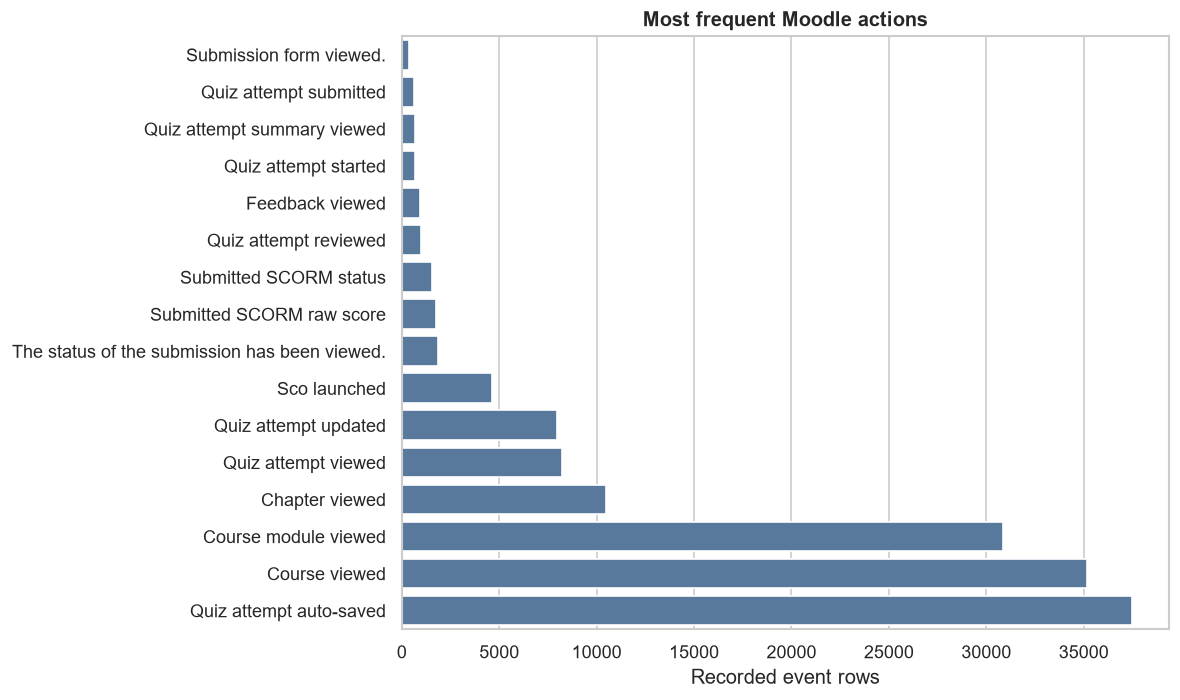

In [612]:
def material_kind(row):
    component = str(row["component"]).lower()
    code = str(row["content_code"]).lower()
    context = str(row["Event context"]).lower()
    if component == "book":
        return "Book chapters"
    if component == "scorm package":
        return "Interactive SCORM"
    if component == "page":
        return "Video/audio pages" if any(x in code + context for x in ["video", "audio", "audiobyte", "recording"]) else "Other learning pages"
    if component == "file":
        if "ppt" in code: return "Lecture slides"
        if "reference" in code: return "Reference files"
        if "self-learning" in code: return "Self-learning files"
        if "additional" in code: return "Supplementary files"
        return "Other files"
    return "Other module"

events["material_kind"] = events.apply(material_kind, axis=1)
events["is_material_access"] = (
    events.event_name.isin(["Chapter viewed", "Sco launched"])
    | (events.event_name.eq("Course module viewed") & events.component.isin(["Book", "Page", "File", "SCORM package"]))
)
events["is_course_home"] = events.event_name.eq("Course viewed")
events["is_forum_interaction"] = events.event_name.isin([
    "Discussion viewed", "Discussion created", "Some content has been posted.", "Discussion subscription created"
])
events["is_forum_module_view"] = events.component.eq("Forum") & events.event_name.eq("Course module viewed")
events["is_material_access"] = events["is_material_access"].fillna(False)
material_events = events.loc[events.is_material_access].copy()
print("Most frequent recorded actions:")
display(events.event_name.value_counts().head(15).rename_axis("Event").reset_index(name="Rows"))
print("Recorded material-access types:")
display(material_events.material_kind.value_counts().rename_axis("Material type").reset_index(name="Access events"))
print("Course-home views are counted separately:", f"{events.is_course_home.sum():,}")

fig, ax = plt.subplots(figsize=(10, 6))
top = events.event_name.value_counts().head(16).sort_values()
sns.barplot(x=top.values, y=top.index, color="#4C78A8", ax=ax)
ax.set(title="Most frequent Moodle actions", xlabel="Recorded event rows", ylabel="")
save_pdf("01_event_actions.pdf")


## 2.2 Dataset structure and what Moodle records

This inventory describes the full event log, including practice quizzes. Each row is one recorded Moodle event. The action grouping below is derived from event name, component, context, and content code; it is an interpretable map for orientation, not an official Moodle taxonomy. Practice quizzes are shown in the inventory but excluded from the quiz research analyses. A view means an access event was logged, not that a learner read or understood the material.

In [614]:
events["activity_group"] = np.select(
    [events.is_practice_quiz,
     events.component.eq("Quiz"),
     events.is_course_home,
     events.is_forum_interaction | events.is_forum_module_view,
     events.component.isin(["Assignment", "File submissions", "Online text submissions"]),
     events.material_kind.isin(["Book chapters", "Lecture slides", "Other learning pages"]),
     events.material_kind.isin(["Reference files", "Self-learning files", "Supplementary files"]),
     events.material_kind.isin(["Interactive SCORM", "Video/audio pages"]),
     events.is_material_access],
    ["Practice quiz (excluded from quiz analysis)", "Non-practice quiz", "Course navigation",
     "Forum and discussion", "Assignment and submission", "Core learning content",
     "Extra-learning content", "Interactive/audio-visual content", "Other recorded material"],
    default="Other/system activity")
course_labels = events["Event context"].astype(str).str.extract(r"^Course:\s*(.+)$", expand=False).dropna().nunique()
structure = pd.DataFrame([
    ["Event rows", f"{len(events):,}"],
    ["Unique learners", f"{events.user_id.nunique():,}"],
    ["Course labels", f"{course_labels:,}"],
    ["Distinct event names", f"{events.event_name.nunique():,}"],
    ["Components", f"{events.component.nunique():,}"],
    ["Date range", f"{events.time.min():%d %b %Y} – {events.time.max():%d %b %Y}"],
], columns=["Dataset measure", "Value"])
display(structure)
activity_summary = events.groupby("activity_group", dropna=False).agg(
    Event_rows=("event_name", "size"), Unique_learners=("user_id", "nunique"),
    Event_types=("event_name", "nunique")).sort_values("Event_rows", ascending=False)
activity_summary["Share_of_rows_pct"] = 100 * activity_summary.Event_rows / len(events)
display(activity_summary.round(1))
print("Action types and their recorded row counts:")
display(events.event_name.value_counts().rename_axis("Event name").reset_index(name="Rows"))
activity_summary.reset_index().to_csv(OUTPUT_DIR / "dataset_activity_inventory.csv", index=False)


,Dataset measure,Value
0,Event rows,"146,048"
1,Unique learners,172
2,Course labels,1
3,Distinct event names,34
4,Components,11
5,Date range,23 Oct 2025 – 29 Jul 2026


,Event_rows,Unique_learners,Event_types,Share_of_rows_pct
activity_group,,,,
Non-practice quiz,42381,155,8,29.0
Course navigation,35186,172,1,24.1
Interactive/audio-visual content,24566,157,4,16.8
Practice quiz (excluded from quiz analysis),16104,88,8,11.0
Core learning content,13462,140,2,9.2
Assignment and submission,6956,99,13,4.8
Extra-learning content,5648,145,1,3.9
Other/system activity,1039,126,7,0.7
Forum and discussion,706,101,5,0.5


Action types and their recorded row counts:


,Event name,Rows
0,Quiz attempt auto-saved,37492
1,Course viewed,35186
2,Course module viewed,30851
3,Chapter viewed,10471
4,Quiz attempt viewed,8243
5,Quiz attempt updated,7985
6,Sco launched,4635
7,The status of the submission has been viewed.,1856
8,Submitted SCORM raw score,1776
9,Submitted SCORM status,1558


## 3. Feature definitions and attempt construction

Each analysis row is a non-practice quiz attempt identified by learner, quiz module, and attempt ID. Quiz events are bounded from the recorded start to the first logged submission, or to the final available event when no submission is logged. Page numbers are parsed from event descriptions.

Quiz-work features include response coverage, unique viewed and answered pages, answer-change rate, median response latency by page, pacing variation (IQR of time between first responses on different pages), post-answer review share, repeated page-view share, active work minutes, submission status, and earlier logged attempts at the same quiz. An answer change is inferred from repeated response-update events on a page; the log does not reveal whether the answer value actually changed or whether it was correct. Latency and pacing are set to zero when they cannot be measured; the page counts show when there was no page-response data to interpret.

Preparation is measured strictly before each attempt in three nested windows: previous 24 hours, previous 7 days, and all available earlier course history. Each window includes core-content access count, distinct core resources, active study days, repeated core-resource visit share, core-access recency, and the longest gap between active study dates. Active study days include core and interactive/media learning material; core access and repeated visits use only book chapters, lecture slides, and learning pages. Access counts, shares, and gaps are zero when no qualifying event or gap is observed. Recency is capped at the window length when there was no core access in that window; for overall history, it is capped at the number of days since the log began. Thus the preparation feature table has no missing values, and zero counts distinguish no access from recent access.

Resource identity uses event context, with content code as a fallback. Categories are inferred from Moodle fields; recorded access is not proof of reading. The window summary table compares the previous day, previous seven days, and all earlier history without boxplots.


In [616]:
KEY = ["user_id", "module_id", "attempt_id"]
all_quiz_start_rows = events.loc[events.event_name.eq("Quiz attempt started")]
practice_quiz_starts = int(all_quiz_start_rows.is_practice_quiz.sum())
nonpractice_start_rows = events.loc[
    events.event_name.eq("Quiz attempt started") & ~events.is_practice_quiz
]
starts = nonpractice_start_rows.loc[
    nonpractice_start_rows[KEY].notna().all(axis=1), KEY + ["time", "Event context"]
].sort_values("time").drop_duplicates(KEY, keep="first")
starts = starts.rename(columns={"time": "start_time", "Event context": "quiz_name"})
submits_raw = events.loc[
    events.event_name.eq("Quiz attempt submitted") & events[KEY].notna().all(axis=1), KEY + ["time"]
].merge(starts[KEY], on=KEY, how="inner")
submits = submits_raw.groupby(KEY, as_index=False)["time"].min().rename(columns={"time": "submit_time"})
cases = starts.merge(submits, on=KEY, how="left")
cases.loc[cases.submit_time.lt(cases.start_time), "submit_time"] = pd.NaT
cases["submitted"] = cases.submit_time.notna()
cases["quiz_submitted"] = cases.submitted.astype(int)
cases["case_id"] = cases[KEY].astype(str).agg("|".join, axis=1)

case_keys = cases[KEY + ["case_id", "start_time", "submit_time"]]
attempt_events = events.loc[
    events.event_name.str.startswith("Quiz attempt", na=False)
    & events.attempt_id.notna() & events.module_id.notna()
].merge(case_keys, on=KEY, how="inner")
attempt_events = attempt_events.loc[
    attempt_events.time.ge(attempt_events.start_time)
    & (attempt_events.submit_time.isna() | attempt_events.time.le(attempt_events.submit_time))
].copy()
page_event_names = ["Quiz attempt viewed", "Quiz attempt updated", "Quiz attempt auto-saved"]
page_parse_audit = attempt_events.loc[attempt_events.event_name.isin(page_event_names)].groupby("event_name").agg(
    Event_rows=("event_name", "size"), Page_numbers_parsed=("page_number", "count")).reindex(page_event_names, fill_value=0)
page_parse_audit["Parsed_share_pct"] = 100 * page_parse_audit.Page_numbers_parsed / page_parse_audit.Event_rows.replace(0, np.nan)
print("Page-number extraction check for retained non-practice attempts:")
display(page_parse_audit.round(1))

# One row per attempt: page coverage, answer updates, timing, review, and submission behaviour.
feature_rows = []
for case_id, group in attempt_events.groupby("case_id", sort=False):
    actions = group.loc[~group.event_name.eq("Quiz attempt started")].sort_values("time")
    views = actions.loc[actions.event_name.eq("Quiz attempt viewed") & actions.page_number.notna(), ["time", "page_number"]].copy()
    updates = actions.loc[actions.event_name.eq("Quiz attempt updated") & actions.page_number.notna(), ["time", "page_number"]].copy()
    view_pages = set(views.page_number.astype(int))
    update_counts = updates.page_number.astype(int).value_counts()
    answer_pages = set(update_counts.index)
    covered_pages = view_pages & answer_pages
    latencies = []
    reviewed_pages = set()
    for page in sorted(covered_pages):
        page_views = views.loc[views.page_number.eq(page), "time"].sort_values()
        page_updates = updates.loc[updates.page_number.eq(page), "time"].sort_values()
        first_view = page_views.iloc[0]
        later_updates = page_updates.loc[page_updates.ge(first_view)]
        if later_updates.empty:
            continue
        first_update = later_updates.iloc[0]
        latencies.append(max(0.0, (first_update - first_view).total_seconds() / 60))
        if (page_views > first_update).any():
            reviewed_pages.add(page)

    first_response_by_page = updates.assign(page_number=updates.page_number.astype(int)).groupby("page_number").time.min().sort_values()
    response_gaps = first_response_by_page.diff().dt.total_seconds().dropna() / 60
    work_times = actions.loc[actions.event_name.isin(["Quiz attempt viewed", "Quiz attempt updated"]), "time"]
    view_event_count = len(views)
    answer_page_count = len(answer_pages)
    feature_rows.append({
        "case_id": case_id,
        "quiz_viewed_pages": int(len(view_pages)),
        "quiz_answered_pages": int(answer_page_count),
        "quiz_covered_pages": int(len(covered_pages)),
        "quiz_response_coverage": len(covered_pages) / len(view_pages) if view_pages else 0.0,
        "quiz_answer_change_rate": float((update_counts >= 2).sum() / answer_page_count) if answer_page_count else 0.0,
        "quiz_median_response_latency_min": float(np.median(latencies)) if latencies else 0.0,
        "quiz_pages_with_latency": int(len(latencies)),
        "quiz_pacing_iqr_min": float(response_gaps.quantile(.75) - response_gaps.quantile(.25)) if len(first_response_by_page) >= 3 else 0.0,
        "quiz_review_page_share": len(reviewed_pages) / answer_page_count if answer_page_count else 0.0,
        "quiz_page_revisit_share": (view_event_count - len(view_pages)) / view_event_count if view_event_count else 0.0,
        "quiz_active_work_minutes": int(work_times.dt.floor("min").nunique()),
    })
cases = cases.merge(pd.DataFrame(feature_rows), on="case_id", how="left")
# Count earlier logged attempts at this same quiz; current submission status comes from the attempt record.
cases = cases.sort_values(["user_id", "module_id", "start_time"]).reset_index(drop=True)
cases["quiz_prior_attempts_same_quiz"] = cases.groupby(["user_id", "module_id"], sort=False).cumcount().astype(int)
QUIZ_FEATURES = ["quiz_response_coverage", "quiz_viewed_pages", "quiz_answered_pages", "quiz_covered_pages",
                 "quiz_answer_change_rate", "quiz_median_response_latency_min", "quiz_pages_with_latency",
                 "quiz_pacing_iqr_min", "quiz_review_page_share", "quiz_page_revisit_share",
                 "quiz_active_work_minutes", "quiz_submitted", "quiz_prior_attempts_same_quiz"]

# Preparation features use only events strictly earlier than each quiz attempt.
resource_events = events.loc[events.is_material_access].sort_values(["user_id", "time"]).copy()
CORE_KINDS = ["Book chapters", "Lecture slides", "Other learning pages"]
MEDIA_KINDS = ["Interactive SCORM", "Video/audio pages"]
STUDY_KINDS = CORE_KINDS + MEDIA_KINDS
study_events = resource_events.loc[resource_events.material_kind.isin(STUDY_KINDS)].copy()
core_events = resource_events.loc[resource_events.material_kind.isin(CORE_KINDS)].copy()
for frame in [study_events, core_events]:
    frame["resource_key"] = frame["Event context"].astype("string").str.strip()
    missing_resource = frame.resource_key.isna() | frame.resource_key.eq("")
    frame.loc[missing_resource, "resource_key"] = frame.loc[missing_resource, "content_code"].astype("string")
    frame["resource_key"] = frame.resource_key.fillna(frame.material_kind)

resources_by_user = {uid: g.reset_index(drop=True) for uid, g in resource_events.groupby("user_id", sort=False)}
study_by_user = {uid: g.reset_index(drop=True) for uid, g in study_events.groupby("user_id", sort=False)}
core_by_user = {uid: g.reset_index(drop=True) for uid, g in core_events.groupby("user_id", sort=False)}
WINDOWS = {"last_day": pd.Timedelta(days=1), "last_7d": pd.Timedelta(days=7), "overall": None}
prep_rows = []
for row in cases.itertuples(index=False):
    # Use empty slices with the expected columns when a learner has no events of a type.
    all_materials = resources_by_user.get(row.user_id, resource_events.iloc[0:0])
    study_history = study_by_user.get(row.user_id, study_events.iloc[0:0])
    core_history = core_by_user.get(row.user_id, core_events.iloc[0:0])
    features = {"case_id": row.case_id}
    for window_name, duration in WINDOWS.items():
        lower = row.start_time - duration if duration is not None else None
        materials = all_materials.loc[all_materials.time.lt(row.start_time)]
        study = study_history.loc[study_history.time.lt(row.start_time)]
        core = core_history.loc[core_history.time.lt(row.start_time)].copy()
        if lower is not None:
            materials = materials.loc[materials.time.ge(lower)]
            study = study.loc[study.time.ge(lower)]
            core = core.loc[core.time.ge(lower)]
        suffix = window_name
        core_count = len(core)
        core_days = pd.Index(core.time.dt.normalize().drop_duplicates()).sort_values() if core_count else pd.DatetimeIndex([])
        study_days = pd.Index(study.time.dt.normalize().drop_duplicates()).sort_values() if len(study) else pd.DatetimeIndex([])
        repeat_share = ((core_count - core.resource_key.nunique()) / core_count) if core_count else 0.0
        gap_days = (np.diff(study_days.values).astype("timedelta64[D]").astype(int) - 1) if len(study_days) >= 2 else np.array([])
        recency_cap = (duration.total_seconds() / 86400) if duration is not None else max(
            0.0, (row.start_time - events.time.min()).total_seconds() / 86400)
        features.update({
            f"prep_core_access_count_{suffix}": int(core_count),
            f"prep_distinct_core_resources_{suffix}": int(core.resource_key.nunique()) if core_count else 0,
            f"prep_active_study_days_{suffix}": int(len(study_days)),
            f"prep_repeat_core_visit_share_{suffix}": float(repeat_share),
            f"prep_core_recency_days_{suffix}": min(float((row.start_time - core.time.max()).total_seconds() / 86400), recency_cap) if core_count else recency_cap,
            f"prep_longest_study_gap_days_{suffix}": int(gap_days.max()) if len(gap_days) else 0,
            f"prep_any_material_access_count_{suffix}": int(len(materials)),
        })
    prep_rows.append(features)
cases = cases.merge(pd.DataFrame(prep_rows), on="case_id", how="left")
PREP_METRICS = ["core_access_count", "distinct_core_resources", "active_study_days",
                "repeat_core_visit_share", "core_recency_days", "longest_study_gap_days"]
WINDOW_SUFFIXES = ["last_day", "last_7d", "overall"]
READ_FEATURES = [f"prep_{metric}_{window}" for metric in PREP_METRICS for window in WINDOW_SUFFIXES]

# Coverage audit distinguishes all Moodle material from the narrower core-content definition.
quiz_learners = int(cases.user_id.nunique())
missing_start_keys = int(nonpractice_start_rows[KEY].isna().any(axis=1).sum())
prep_audit_rows = [
    ["Learners in full event log", int(events.user_id.nunique())],
    ["Learners with a non-practice quiz attempt", quiz_learners],
    ["Non-practice attempts retained", len(cases)],
    ["Practice quiz starts excluded", practice_quiz_starts],
    ["Start rows missing parsed attempt keys", missing_start_keys],
    ["Duplicate retained attempt keys", int(cases.duplicated(KEY).sum())],
]
for window in WINDOW_SUFFIXES:
    any_attempts = int(cases[f"prep_any_material_access_count_{window}"].gt(0).sum())
    any_learners = int(cases.groupby("user_id")[f"prep_any_material_access_count_{window}"].max().gt(0).sum())
    core_attempts = int(cases[f"prep_core_access_count_{window}"].gt(0).sum())
    prep_audit_rows.extend([
        [f"Attempts with any material access ({window})", f"{any_attempts} / {len(cases)} ({100*any_attempts/max(1,len(cases)):.1f}%)"],
        [f"Quiz-takers with any material access ({window})", f"{any_learners} / {quiz_learners} ({100*any_learners/max(1,quiz_learners):.1f}%)"],
        [f"Attempts with core-content access ({window})", f"{core_attempts} / {len(cases)} ({100*core_attempts/max(1,len(cases)):.1f}%)"],
    ])
display(pd.DataFrame(prep_audit_rows, columns=["Audit check", "Result"]))
print("Response coverage is updated pages divided by viewed pages; it does not measure answer correctness.")
print("Answer-change rate counts pages with multiple logged response updates; the log does not show whether values changed.")
print("No-access recency is capped at the window length; an unobserved inter-day gap is zero. Counts show whether any access occurred.")
display(cases[["quiz_name", "quiz_submitted"] + QUIZ_FEATURES + READ_FEATURES].head(8))

# Show distributions and compact summaries for all three preparation horizons.
window_labels = {"last_day": "Previous 24 hours", "last_7d": "Previous 7 days", "overall": "All earlier history"}
metric_labels = {
    "core_access_count": "Core-content accesses",
    "distinct_core_resources": "Distinct core resources",
    "active_study_days": "Active study days",
    "repeat_core_visit_share": "Repeated core-visit share",
    "core_recency_days": "Days since core access",
    "longest_study_gap_days": "Longest gap between study days",
}
window_summary_rows = []
for metric in PREP_METRICS:
    for window in WINDOW_SUFFIXES:
        col = f"prep_{metric}_{window}"
        values = cases[col].dropna()
        window_summary_rows.append({"Measure": metric_labels[metric], "Window": window_labels[window],
                                    "Attempts": len(cases), "Missing": int(cases[col].isna().sum()),
                                    "Median": values.median() if len(values) else np.nan,
                                    "IQR": values.quantile(.75) - values.quantile(.25) if len(values) else np.nan})
prep_window_summary = pd.DataFrame(window_summary_rows)
display(prep_window_summary.round(2))



Page-number extraction check for retained non-practice attempts:


,Event_rows,Page_numbers_parsed,Parsed_share_pct
event_name,,,
Quiz attempt viewed,4484,4484,100.0
Quiz attempt updated,4353,4353,100.0
Quiz attempt auto-saved,30649,30649,100.0


,Audit check,Result
0,Learners in full event log,172
1,Learners with a non-practice quiz attempt,152
2,Non-practice attempts retained,403
3,Practice quiz starts excluded,262
4,Start rows missing parsed attempt keys,0
5,Duplicate retained attempt keys,0
6,Attempts with any material access (last_day),56 / 403 (13.9%)
7,Quiz-takers with any material access (last_day),29 / 152 (19.1%)
8,Attempts with core-content access (last_day),31 / 403 (7.7%)
9,Attempts with any material access (last_7d),146 / 403 (36.2%)


Response coverage is updated pages divided by viewed pages; it does not measure answer correctness.
Answer-change rate counts pages with multiple logged response updates; the log does not show whether values changed.
No-access recency is capped at the window length; an unobserved inter-day gap is zero. Counts show whether any access occurred.


,quiz_name,quiz_submitted,quiz_response_coverage,quiz_viewed_pages,quiz_answered_pages,quiz_covered_pages,quiz_answer_change_rate,quiz_median_response_latency_min,quiz_pages_with_latency,quiz_pacing_iqr_min,...,prep_active_study_days_overall,prep_repeat_core_visit_share_last_day,prep_repeat_core_visit_share_last_7d,prep_repeat_core_visit_share_overall,prep_core_recency_days_last_day,prep_core_recency_days_last_7d,prep_core_recency_days_overall,prep_longest_study_gap_days_last_day,prep_longest_study_gap_days_last_7d,prep_longest_study_gap_days_overall
0,Quiz: IT_EE_Section-A,1,1.0,12,12,12,0.166667,0.000000,8,0.408333,...,3,0.0,0.000000,0.943662,1.0,7.000000,63.662118,0,0,16
1,Quiz: IT_EE_Section-CQ,1,1.0,12,12,12,0.166667,0.000000,7,0.383333,...,3,0.0,0.000000,0.943662,1.0,7.000000,62.955937,0,0,16
2,Quiz: IT_EE_Section-C,1,1.0,1,1,1,0.000000,11.283333,1,0.000000,...,3,0.0,0.000000,0.943662,1.0,7.000000,63.695081,0,0,16
3,Quiz: IT_EE_Section-A,1,1.0,12,12,12,0.500000,0.000000,11,1.666667,...,9,0.0,0.000000,0.111111,1.0,7.000000,32.346134,0,0,20
4,Quiz: IT_EE_Section-A,1,1.0,11,12,11,0.000000,0.000000,10,1.291667,...,0,0.0,0.000000,0.000000,1.0,7.000000,128.375984,0,0,0
5,Quiz: IT_EE_Section-CQ,1,1.0,12,12,12,0.416667,0.000000,12,0.333333,...,0,0.0,0.000000,0.000000,1.0,7.000000,128.388993,0,0,0
6,Quiz: IT_EE_Section-A,1,1.0,11,12,11,0.000000,0.000000,3,0.416667,...,16,0.0,0.833333,0.962963,1.0,3.725336,3.725336,0,0,10
7,Quiz: IT_EE_Section-CQ,1,1.0,11,12,11,0.000000,0.000000,10,0.233333,...,16,0.0,0.833333,0.962963,1.0,3.793657,3.793657,0,0,10


,Measure,Window,Attempts,Missing,Median,IQR
0,Core-content accesses,Previous 24 hours,403,0,0.00,0.00
1,Core-content accesses,Previous 7 days,403,0,0.00,0.00
2,Core-content accesses,All earlier history,403,0,27.00,77.00
3,Distinct core resources,Previous 24 hours,403,0,0.00,0.00
4,Distinct core resources,Previous 7 days,403,0,0.00,0.00
5,Distinct core resources,All earlier history,403,0,9.00,14.00
6,Active study days,Previous 24 hours,403,0,0.00,0.00
7,Active study days,Previous 7 days,403,0,0.00,1.00
8,Active study days,All earlier history,403,0,5.00,6.00
9,Repeated core-visit share,Previous 24 hours,403,0,0.00,0.00


## 4. RQ1: preparation-to-quiz associations and regression

The correlation matrices compare preparation measures in three time windows with quiz coverage, answer changes, response timing, review behavior, submission, and earlier attempts. Statistics use learner-level averages so repeat attempts do not inflate the apparent learner count. Spearman is useful here because event counts are skewed and contain many zeros; it measures monotonic rank association, not every nonlinear pattern. Benjamini–Hochberg q-values adjust for the many feature comparisons.

The Ridge check predicts response-page coverage from selected preparation features, holds out entire learners, and compares with a mean-only baseline. This is a workflow proxy, not score prediction. K-Means uses a separate imputation and scaling pipeline in RQ3.


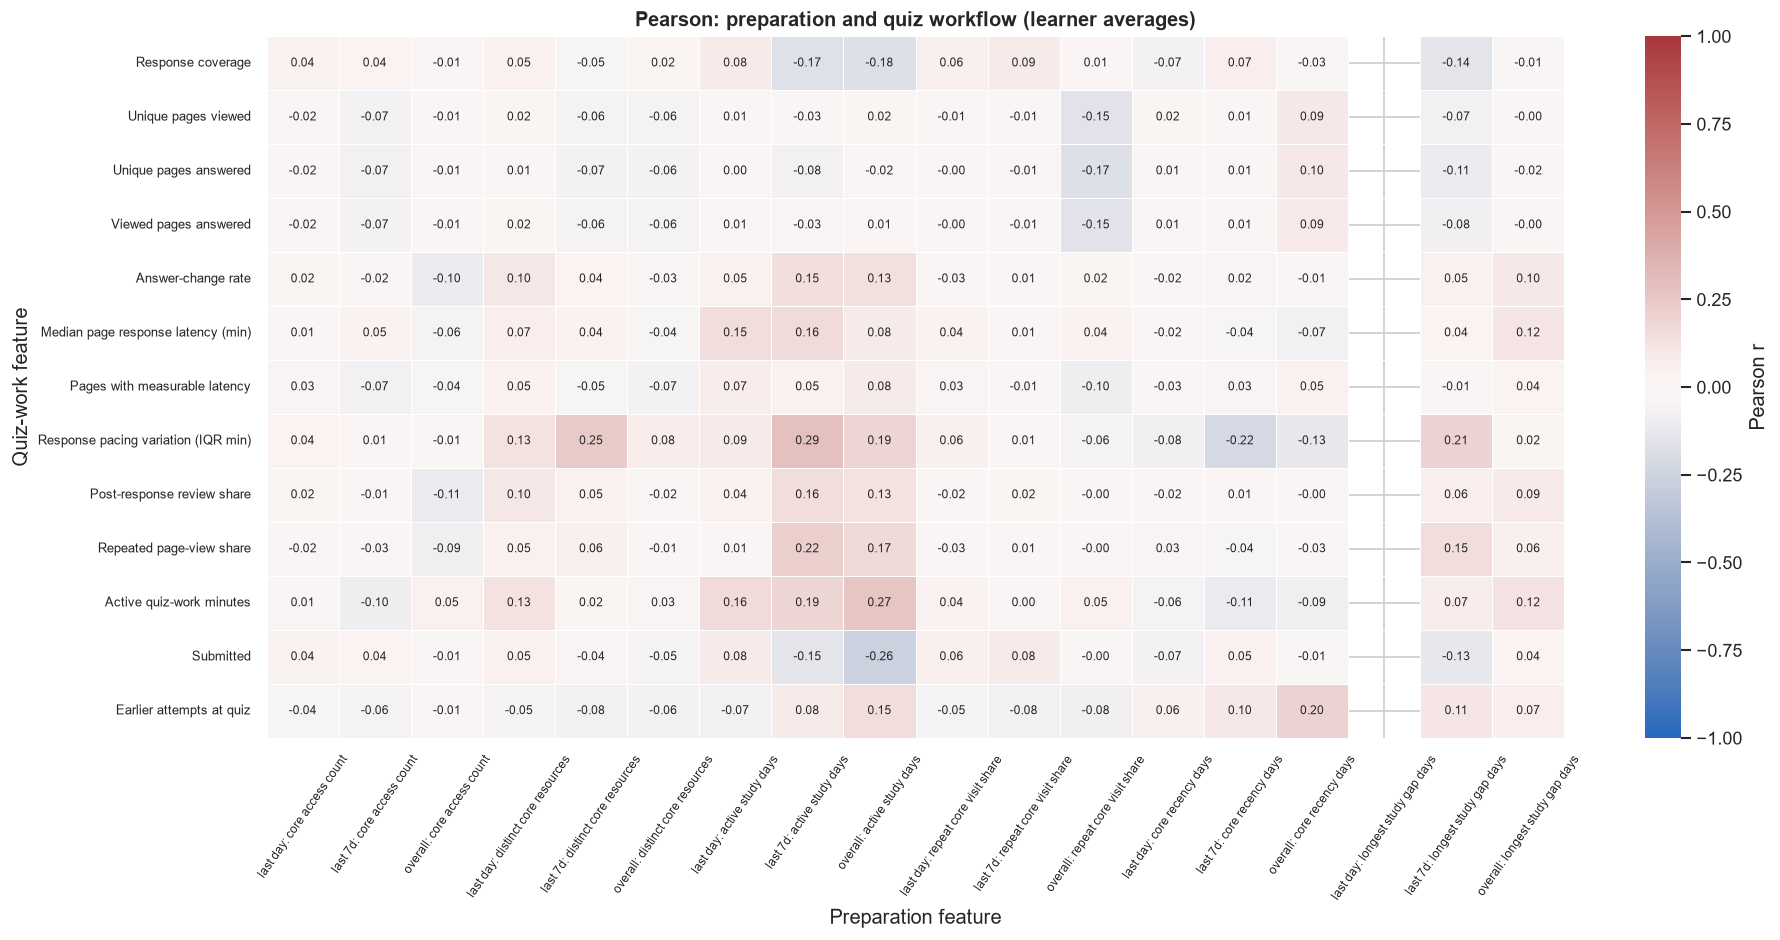

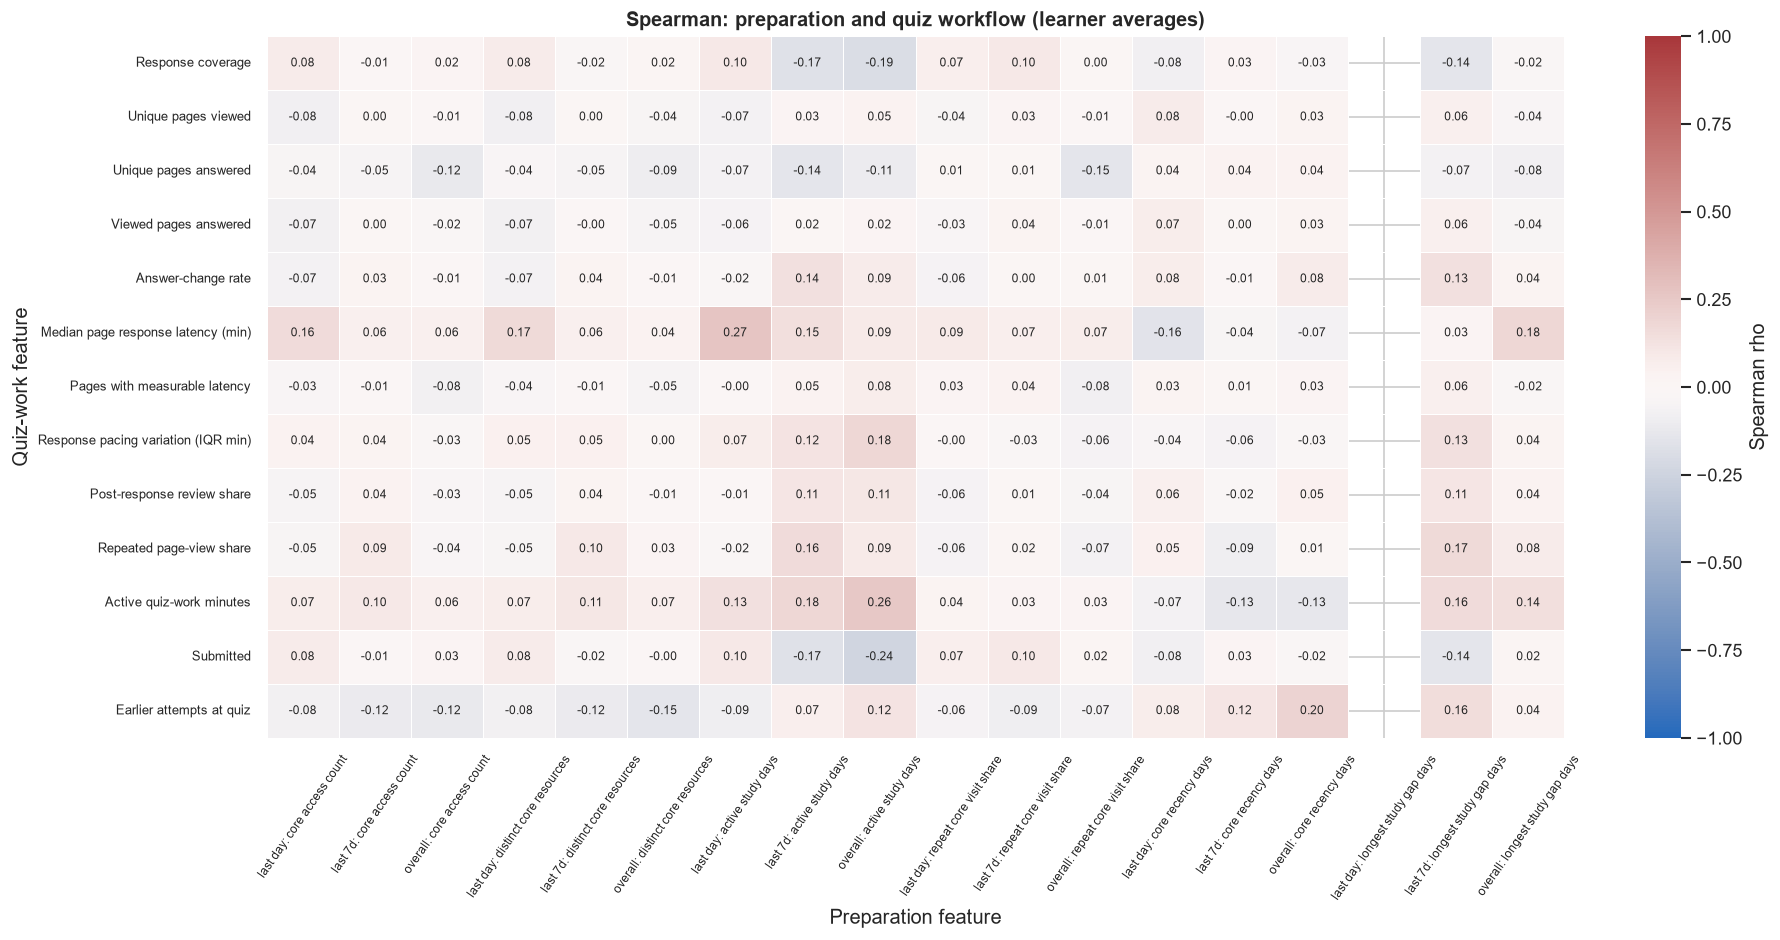

Every prep × quiz pair, with both coefficients, p-values, FDR q-values, and learner count:


,Preparation feature,Quiz feature,Learners,Pearson r,Pearson p,Spearman rho,Spearman p,Pearson q (BH),Spearman q (BH)
0,prep_core_access_count_last_day,quiz_response_coverage,152,0.044,0.589,0.083,0.307,0.988,0.956
1,prep_core_access_count_last_7d,quiz_response_coverage,152,0.035,0.665,-0.011,0.889,0.988,0.992
2,prep_core_access_count_overall,quiz_response_coverage,152,-0.012,0.882,0.024,0.770,0.988,0.957
3,prep_distinct_core_resources_last_day,quiz_response_coverage,152,0.054,0.510,0.083,0.307,0.988,0.956
4,prep_distinct_core_resources_last_7d,quiz_response_coverage,152,-0.046,0.576,-0.024,0.769,0.988,0.957
...,...,...,...,...,...,...,...,...,...
229,prep_core_recency_days_last_7d,quiz_prior_attempts_same_quiz,152,0.098,0.229,0.117,0.152,0.988,0.910
230,prep_core_recency_days_overall,quiz_prior_attempts_same_quiz,152,0.198,0.015,0.203,0.012,0.395,0.672
231,prep_longest_study_gap_days_last_day,quiz_prior_attempts_same_quiz,152,NaN,NaN,NaN,NaN,NaN,NaN
232,prep_longest_study_gap_days_last_7d,quiz_prior_attempts_same_quiz,152,0.110,0.176,0.156,0.055,0.988,0.709


Pairs significant after FDR correction:


,Result
0,No pair meets q < .05 after correction.


,Quiz feature,Tested_prep_features,Significant_Pearson_features,Significant_Spearman_features,Strongest_abs_spearman
0,quiz_active_work_minutes,18,0,0,0.258
1,quiz_answer_change_rate,18,0,0,0.140
2,quiz_answered_pages,18,0,0,0.146
3,quiz_covered_pages,18,0,0,0.072
4,quiz_median_response_latency_min,18,0,0,0.266
5,quiz_pacing_iqr_min,18,0,0,0.181
6,quiz_page_revisit_share,18,0,0,0.166
7,quiz_pages_with_latency,18,0,0,0.084
8,quiz_prior_attempts_same_quiz,18,0,0,0.203
9,quiz_response_coverage,18,0,0,0.191


,Response-coverage regression,Result
0,Target,Updated pages / viewed pages (not quiz marks)
1,Train / held-out attempts,305 / 98
2,Learners held out,38
3,Preparation predictors,"prep_core_access_count_overall, prep_active_st..."
4,Ridge held-out R-squared,-0.018
5,Ridge held-out MAE,0.042
6,Mean-baseline held-out R-squared,-0.000
7,Mean-baseline held-out MAE,0.039


,Preparation feature,Standardized Ridge coefficient
1,prep_active_study_days_overall,-0.022573
3,prep_core_access_count_last_day,0.004351
0,prep_core_access_count_overall,0.004310
2,prep_core_access_count_last_7d,0.001708


In [618]:
# Correlation matrix: learner-level preparation × quiz workflow.
student = cases.groupby("user_id")[READ_FEATURES + QUIZ_FEATURES].mean()

def bh_qvalues(pvalues):
    values = np.asarray(pvalues, dtype=float)
    q = np.full(values.shape, np.nan)
    valid = np.isfinite(values)
    if valid.sum() == 0: return q
    pv = values[valid]
    order = np.argsort(pv)
    ranked = pv[order] * len(pv) / np.arange(1, len(pv) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q_valid = np.empty_like(ranked)
    q_valid[order] = np.minimum(ranked, 1.0)
    q[valid] = q_valid
    return q

prep_window_display = {
    f"prep_{metric}_{window}": f"{window.replace('_', ' ')}: {metric.replace('_', ' ')}"
    for metric in PREP_METRICS for window in WINDOW_SUFFIXES
}
quiz_display = {
    "quiz_response_coverage": "Response coverage",
    "quiz_viewed_pages": "Unique pages viewed",
    "quiz_answered_pages": "Unique pages answered",
    "quiz_covered_pages": "Viewed pages answered",
    "quiz_answer_change_rate": "Answer-change rate",
    "quiz_median_response_latency_min": "Median page response latency (min)",
    "quiz_pages_with_latency": "Pages with measurable latency",
    "quiz_pacing_iqr_min": "Response pacing variation (IQR min)",
    "quiz_review_page_share": "Post-response review share",
    "quiz_page_revisit_share": "Repeated page-view share",
    "quiz_active_work_minutes": "Active quiz-work minutes",
    "quiz_submitted": "Submitted",
    "quiz_prior_attempts_same_quiz": "Earlier attempts at quiz",
}

corr_rows = []
for quiz_feature in QUIZ_FEATURES:
    for prep_feature in READ_FEATURES:
        pair = student[[prep_feature, quiz_feature]].dropna()
        n = len(pair)
        row = {"Preparation feature": prep_feature, "Quiz feature": quiz_feature, "Learners": n,
               "Pearson r": np.nan, "Pearson p": np.nan, "Spearman rho": np.nan, "Spearman p": np.nan}
        if n >= 10 and pair[prep_feature].nunique() > 1 and pair[quiz_feature].nunique() > 1:
            row["Pearson r"], row["Pearson p"] = stats.pearsonr(pair[prep_feature], pair[quiz_feature])
            row["Spearman rho"], row["Spearman p"] = stats.spearmanr(pair[prep_feature], pair[quiz_feature])
        corr_rows.append(row)
cross = pd.DataFrame(corr_rows)
cross["Pearson q (BH)"] = bh_qvalues(cross["Pearson p"])
cross["Spearman q (BH)"] = bh_qvalues(cross["Spearman p"])

# Two prep × quiz heatmaps; asterisk means FDR q < .05 across tested feature pairs.
for method, qcol, filename, title in [
    ("Pearson r", "Pearson q (BH)", "02a_prep_quiz_pearson.pdf", "Pearson: preparation and quiz workflow"),
    ("Spearman rho", "Spearman q (BH)", "02b_prep_quiz_spearman.pdf", "Spearman: preparation and quiz workflow"),
]:
    values = cross.pivot(index="Quiz feature", columns="Preparation feature", values=method).reindex(index=QUIZ_FEATURES, columns=READ_FEATURES)
    qvalues = cross.pivot(index="Quiz feature", columns="Preparation feature", values=qcol).reindex(index=QUIZ_FEATURES, columns=READ_FEATURES)
    values = values.rename(index=quiz_display, columns=prep_window_display)
    qvalues = qvalues.rename(index=quiz_display, columns=prep_window_display)
    annotations = values.copy().astype(object)
    for quiz_feature in values.index:
        for prep_feature in values.columns:
            value, qvalue = values.loc[quiz_feature, prep_feature], qvalues.loc[quiz_feature, prep_feature]
            annotations.loc[quiz_feature, prep_feature] = "" if pd.isna(value) else f"{value:.2f}{'*' if pd.notna(qvalue) and qvalue < .05 else ''}"
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(values, cmap="vlag", center=0, vmin=-1, vmax=1, annot=annotations, fmt="",
                linewidths=.3, annot_kws={"size": 7}, ax=ax, cbar_kws={"label": method})
    ax.set(title=title + " (learner averages)", xlabel="Preparation feature", ylabel="Quiz-work feature")
    ax.tick_params(axis="x", rotation=55, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    save_pdf(filename)

print("Every prep × quiz pair, with both coefficients, p-values, FDR q-values, and learner count:")
display(cross.round(3))
significant_pairs = cross.loc[(cross["Pearson q (BH)"].lt(.05)) | (cross["Spearman q (BH)"].lt(.05))]
print("Pairs significant after FDR correction:")
display(significant_pairs.round(3) if not significant_pairs.empty else pd.DataFrame({"Result": ["No pair meets q < .05 after correction."]}))
association_summary = cross.groupby("Quiz feature", as_index=False).agg(
    Tested_prep_features=("Preparation feature", "count"),
    Significant_Pearson_features=("Pearson q (BH)", lambda x: int(x.lt(.05).sum())),
    Significant_Spearman_features=("Spearman q (BH)", lambda x: int(x.lt(.05).sum())),
    Strongest_abs_spearman=("Spearman rho", lambda x: float(x.abs().max()) if x.notna().any() else np.nan))
display(association_summary.round(3))

# Preselected compact regression: predict response-page coverage from four distinct
# preparation concepts. Split by learner so repeat attempts cannot cross the split.
REGRESSION_FEATURES = ["prep_core_access_count_overall", "prep_active_study_days_overall",
                       "prep_core_access_count_last_7d", "prep_core_access_count_last_day"]
model_data = cases.dropna(subset=["quiz_response_coverage"]).copy()
split = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=42)
train_idx, test_idx = next(split.split(model_data, groups=model_data.user_id))
train, test = model_data.iloc[train_idx], model_data.iloc[test_idx]
if train.quiz_response_coverage.nunique() > 1:
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    baseline = make_pipeline(DummyRegressor(strategy="mean"))
    ridge.fit(train[REGRESSION_FEATURES], train.quiz_response_coverage)
    baseline.fit(train[REGRESSION_FEATURES], train.quiz_response_coverage)
    ridge_pred = ridge.predict(test[REGRESSION_FEATURES])
    baseline_pred = baseline.predict(test[REGRESSION_FEATURES])
    regression_table = pd.DataFrame([
        ["Target", "Updated pages / viewed pages (not quiz marks)"],
        ["Train / held-out attempts", f"{len(train):,} / {len(test):,}"],
        ["Learners held out", test.user_id.nunique()],
        ["Preparation predictors", ", ".join(REGRESSION_FEATURES)],
        ["Ridge held-out R-squared", f"{r2_score(test.quiz_response_coverage, ridge_pred):.3f}"],
        ["Ridge held-out MAE", f"{mean_absolute_error(test.quiz_response_coverage, ridge_pred):.3f}"],
        ["Mean-baseline held-out R-squared", f"{r2_score(test.quiz_response_coverage, baseline_pred):.3f}"],
        ["Mean-baseline held-out MAE", f"{mean_absolute_error(test.quiz_response_coverage, baseline_pred):.3f}"],
    ], columns=["Response-coverage regression", "Result"])
    coefficients = pd.DataFrame({"Preparation feature": REGRESSION_FEATURES,
                                 "Standardized Ridge coefficient": ridge[-1].coef_}).sort_values(
                                     "Standardized Ridge coefficient", key=lambda x: x.abs(), ascending=False)
    display(regression_table)
    display(coefficients)
else:
    regression_table = pd.DataFrame([["Status", "Skipped: response coverage has no training variation."]], columns=["Response-coverage regression", "Result"])
    coefficients = pd.DataFrame()
    display(regression_table)


### RQ1 results in plain language

No preparation–quiz pair remains statistically significant after correcting for the many comparisons, and the held-out Ridge model does not beat the mean-only baseline (R² = −0.018 vs approximately 0; MAE = 0.042 vs 0.039). So RQ1 does **not** show a reliable preparation feature that explains quiz workflow in this dataset.

Some Spearman patterns are worth describing cautiously: last-day active study days and median response latency have the largest absolute correlation (ρ = 0.266, unadjusted p = 0.0009, adjusted q = 0.150); overall active study days and quiz-work minutes have ρ = 0.258 (q = 0.150); overall active study days and submission have ρ = −0.239 (q = 0.219). These are weak-to-modest exploratory correlations; none passes the correction threshold, and they do not imply cause or better quiz performance.

## 5. Temporal behaviour

Calendar-week graphs show course activity over time. The profile panel includes zero-access weeks and reports the share of learners active in materials. Quiz starts and logged submissions are shown separately; submission indicates recorded completion, not a score.


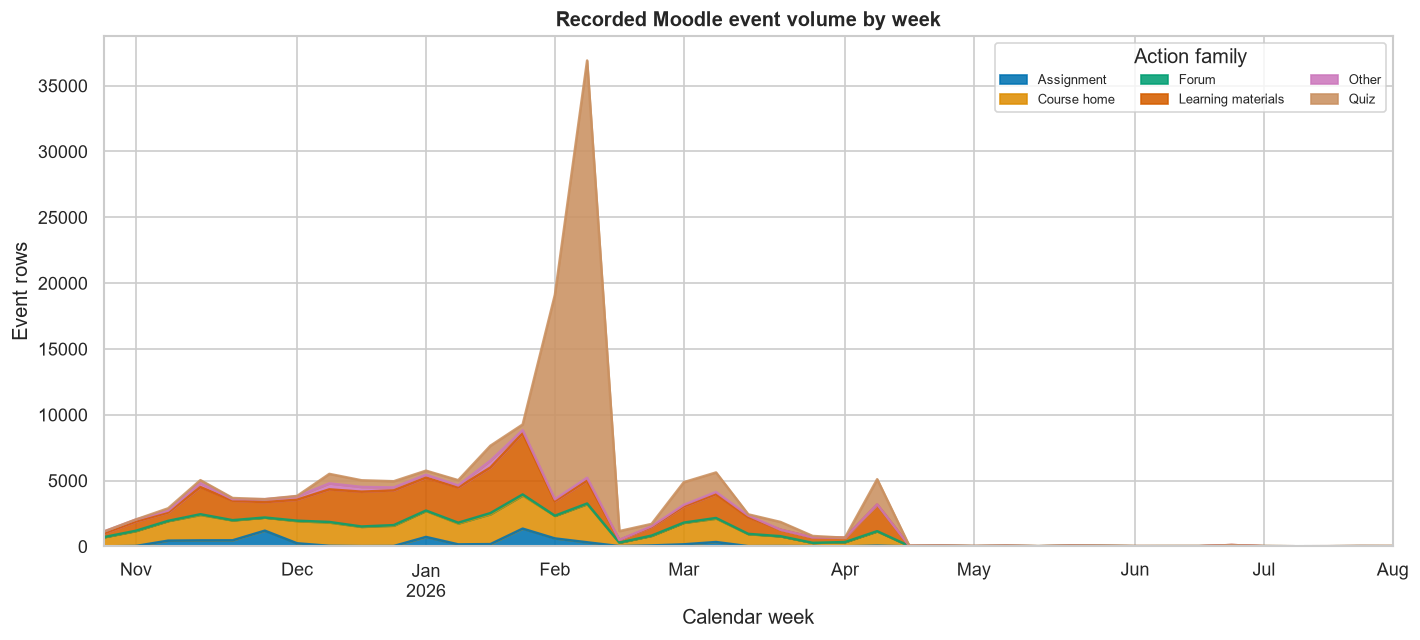

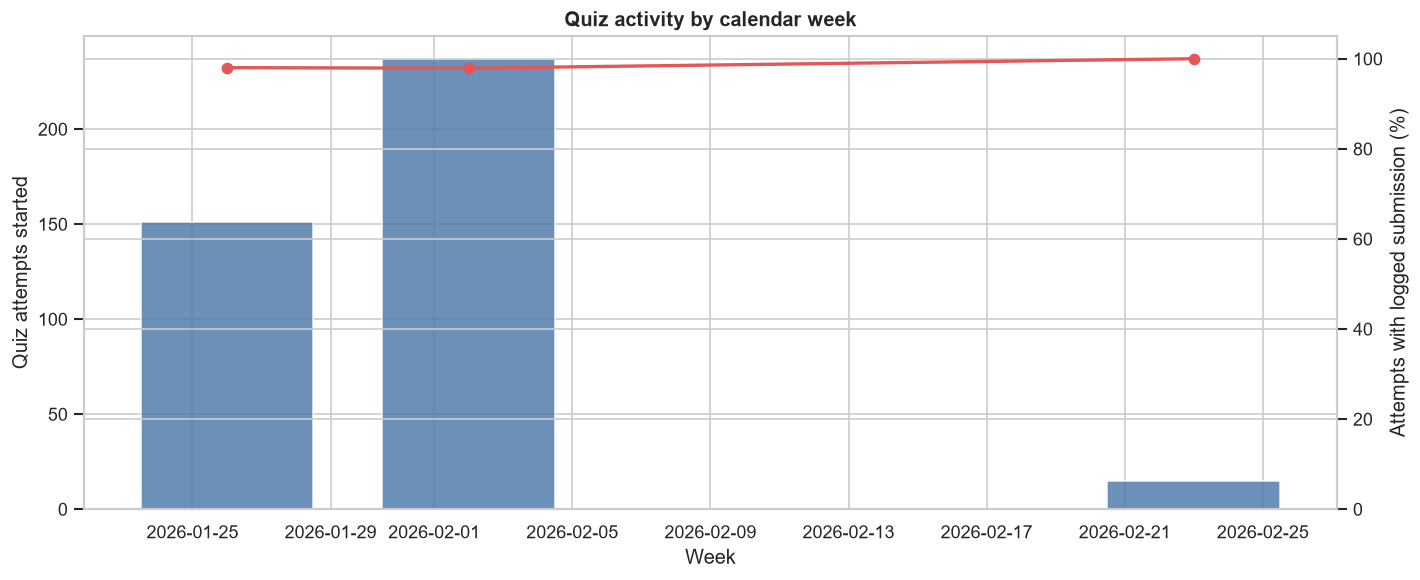

In [620]:
events["event_family"] = np.select(
    [events.is_material_access, events.is_course_home, events.component.eq("Quiz"),
     events.component.isin(["Assignment", "File submissions", "Online text submissions"]),
     events.component.eq("Forum")],
    ["Learning materials", "Course home", "Quiz", "Assignment", "Forum"], default="Other"
)
weekly = events.set_index("time").groupby([pd.Grouper(freq="W"), "event_family"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5.5))
weekly.plot.area(ax=ax, alpha=.88)
ax.set(title="Recorded Moodle event volume by week", xlabel="Calendar week", ylabel="Event rows")
ax.legend(title="Action family", ncol=3, fontsize=8)
save_pdf("03_weekly_event_families.pdf")

quiz_week = cases.assign(week=cases.start_time.dt.to_period("W").dt.start_time).groupby("week").agg(
    starts=("case_id", "size"), submitted=("submitted", "sum"))
quiz_week["submit_share_pct"] = 100 * quiz_week.submitted / quiz_week.starts
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(quiz_week.index, quiz_week.starts, width=5, color="#4C78A8", alpha=.82)
ax1.set(title="Quiz activity by calendar week", xlabel="Week", ylabel="Quiz attempts started")
ax2 = ax1.twinx()
ax2.plot(quiz_week.index, quiz_week.submit_share_pct, color="#E45756", marker="o", linewidth=2)
ax2.set_ylabel("Attempts with logged submission (%)")
ax2.set_ylim(0, 105)
save_pdf("04_weekly_quiz_activity.pdf")



## 6. RQ2: What preparation appears before quizzes?

**RQ2:** Which materials do learners access before a non-practice quiz, and is core-material access absent, concentrated on one day, or spread across days?

**Material definitions:** *Core* means Book chapters, Lecture slides (files whose Content code contains `ppt`), and learning pages not marked video/audio. *Extra-learning* means Reference, Self-learning, and Supplementary files. Interactive SCORM and video/audio pages are grouped as *interactive/media*. These are logged accesses, not proof of reading or understanding. Practice quizzes are excluded.

The three tests below use learner-level summaries and Holm-adjusted p-values. H2 is exploratory. H3 is a two-sided comparison: a significant result can favor either single-day or multi-day preparation; report the direction instead of claiming multi-day preparation is better. H1–H3 test access behavior, not quiz scores.


Attempts with 14-day history: 399; with 28-day history: 392.
Core = books, slides, and learning pages; the final-day window is the 24 hours before quiz start.


,Material group,Eligible learners,Learners with any access (%),Mean accesses per attempt,Median active days per attempt,Median distinct resources per attempt
0,Core,148,56.08,27.00,1.0,1.67
1,Extra-learning,148,56.76,11.22,1.0,2.50
2,Interactive/media,148,68.92,42.20,1.0,3.00
3,Other material,148,0.00,0.00,0.0,0.00


,Material group,Week before quiz,Attempts with access (%),mean_accesses_per_attempt,learners
0,Core,1,19.37,4.94,148
1,Core,2,17.34,5.21,148
2,Core,3,21.06,9.11,148
3,Core,4,17.34,7.74,148
4,Extra-learning,1,24.32,4.10,148
5,Extra-learning,2,18.36,2.66,148
6,Extra-learning,3,18.75,2.66,148
7,Extra-learning,4,16.61,1.80,148
8,Interactive/media,1,23.48,7.60,148
9,Interactive/media,2,23.37,11.54,148


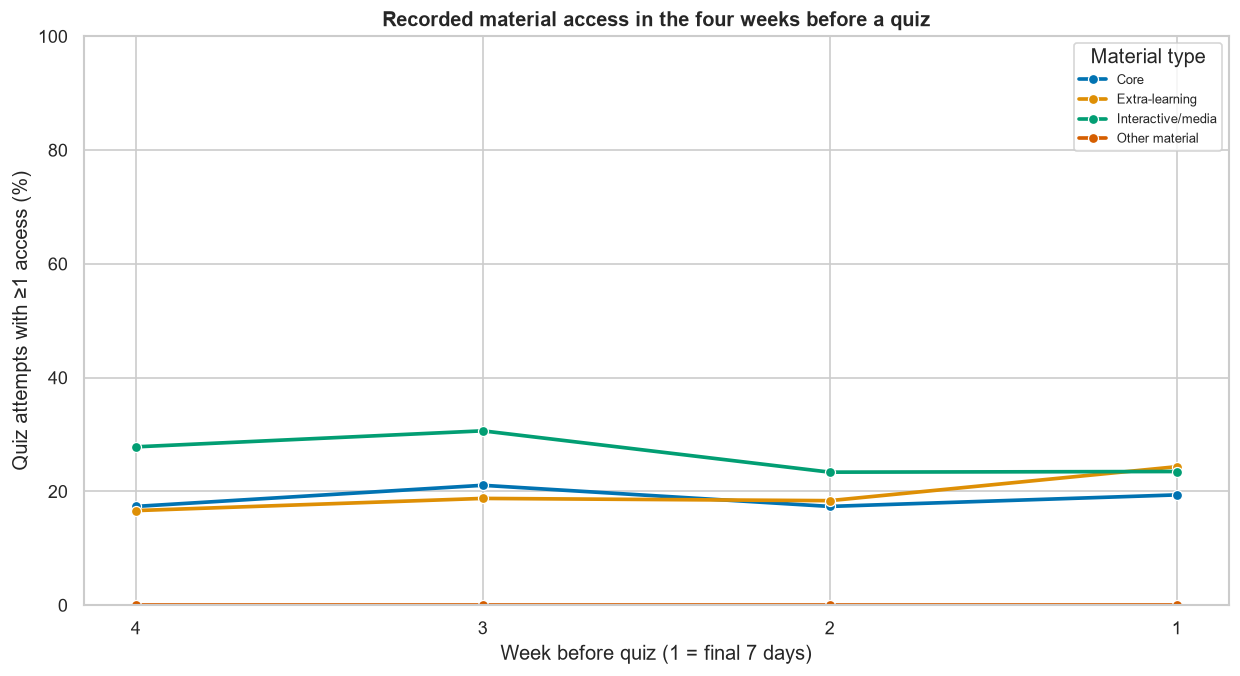

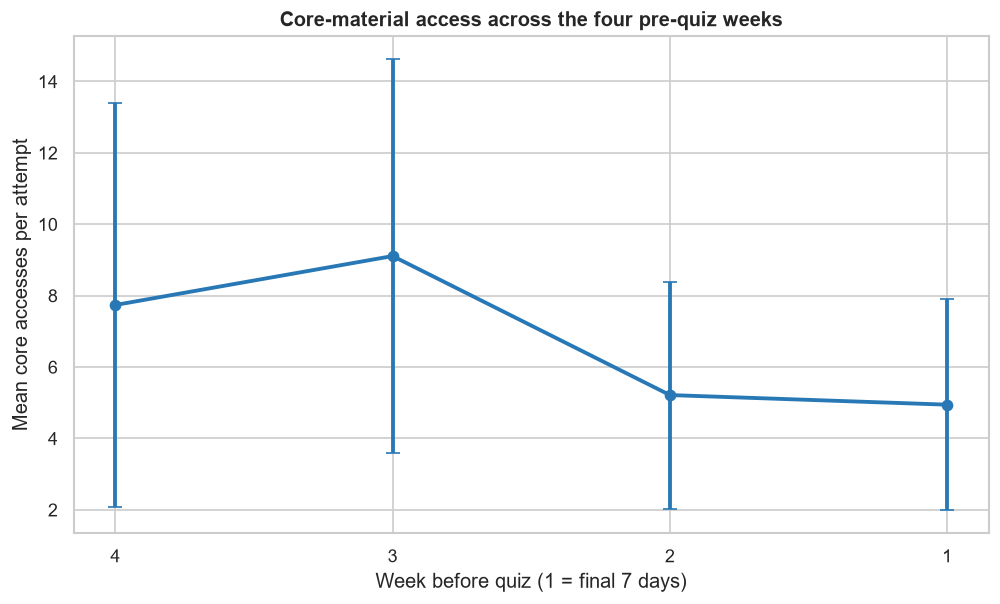

In [622]:
# Build attempt-relative material features with the same material-access rules defined above.
R0_CORE_KINDS = ["Book chapters", "Lecture slides", "Other learning pages"]
R0_EXTRA_KINDS = ["Reference files", "Self-learning files", "Supplementary files"]
R0_MEDIA_KINDS = ["Interactive SCORM", "Video/audio pages"]
R0_GROUPS = {
    "Core": R0_CORE_KINDS,
    "Extra-learning": R0_EXTRA_KINDS,
    "Interactive/media": R0_MEDIA_KINDS,
    "Other material": ["Other files"],
}

r0_materials = resource_events.copy()
r0_materials["r0_material_group"] = r0_materials.material_kind.map(
    {kind: group for group, kinds in R0_GROUPS.items() for kind in kinds}
)
r0_materials = r0_materials.loc[r0_materials.r0_material_group.notna()].copy()
r0_materials["r0_resource_key"] = r0_materials["Event context"].astype("string").str.strip()
r0_missing_key = r0_materials.r0_resource_key.isna() | r0_materials.r0_resource_key.eq("")
r0_materials.loc[r0_missing_key, "r0_resource_key"] = r0_materials.loc[r0_missing_key, "content_code"].astype("string")
r0_materials["r0_resource_key"] = r0_materials.r0_resource_key.fillna(r0_materials.material_kind)
r0_by_user = {uid: frame.sort_values("time").reset_index(drop=True)
              for uid, frame in r0_materials.groupby("user_id", sort=False)}
r0_first_log = events.groupby("user_id").time.min()
r0_feature_rows, r0_timeline_rows = [], []

for row in cases.itertuples(index=False):
    first_time = r0_first_log.get(row.user_id, row.start_time)
    observable_days = (row.start_time - first_time).total_seconds() / 86400
    if observable_days < 14:
        continue
    history = r0_by_user.get(row.user_id, r0_materials.iloc[0:0])
    history = history.loc[(history.time < row.start_time)
                          & (history.time >= row.start_time - pd.Timedelta(days=28))].copy()
    days_before = (row.start_time - history.time).dt.total_seconds() / 86400
    history["relative_week"] = np.ceil(days_before / 7).astype(int)
    history = history.loc[history.relative_week.between(1, 4)]
    feature = {"case_id": row.case_id, "user_id": row.user_id,
               "observable_days": observable_days,
               "quiz_active_work_minutes": row.quiz_active_work_minutes}
    for group_name in R0_GROUPS:
        group_history = history.loc[history.r0_material_group.eq(group_name)]
        for week in range(1, 5):
            week_history = group_history.loc[group_history.relative_week.eq(week)]
            count = len(week_history)
            feature[f"{group_name}_week{week}_accesses"] = int(count)
            r0_timeline_rows.append({"case_id": row.case_id, "user_id": row.user_id,
                                     "Material group": group_name,
                                     "Week before quiz": week, "Access events": int(count)})
        feature[f"{group_name}_28d_active_days"] = int(group_history.time.dt.normalize().nunique())
        feature[f"{group_name}_28d_distinct_resources"] = int(group_history.r0_resource_key.nunique())

    core = history.loc[history.r0_material_group.eq("Core")].copy()
    core_days_before = (row.start_time - core.time).dt.total_seconds() / 86400
    last_day = core_days_before.le(1)
    days_2_7 = core_days_before.gt(1) & core_days_before.le(7)
    feature["Core_last24h_accesses"] = int(last_day.sum())
    feature["Core_days2_7_accesses"] = int(days_2_7.sum())
    feature["Core_days2_7_active_days"] = int(core.loc[days_2_7, "time"].dt.normalize().nunique())
    feature["Core_week1_active_days"] = int(core.loc[core_days_before.le(7), "time"].dt.normalize().nunique())
    feature["Core_last24h_distinct_resources"] = int(core.loc[last_day, "r0_resource_key"].nunique())
    feature["Core_days2_7_distinct_resources"] = int(core.loc[days_2_7, "r0_resource_key"].nunique())
    core_week = core.loc[core_days_before.le(7)].copy()
    feature["Core_week1_distinct_resources"] = int(core_week.r0_resource_key.nunique())
    feature["Core_week1_active_day_share"] = feature["Core_week1_active_days"] / 7
    feature["Core_last24h_access_share"] = (
        feature["Core_last24h_accesses"] / len(core_week) if len(core_week) else 0.0
    )
    resource_dates = core_week.assign(
        _access_date=core_week.time.dt.normalize()
    ).groupby("r0_resource_key")._access_date.nunique()
    revisited_resources = set(resource_dates.loc[resource_dates.ge(2)].index)
    feature["Core_week1_revisited_resources"] = len(revisited_resources)
    feature["Core_week1_revisit_event_share"] = (
        float(core_week.r0_resource_key.isin(revisited_resources).mean()) if len(core_week) else 0.0
    )
    feature["Core_week1_recency_hours"] = (
        float((row.start_time - core_week.time.max()).total_seconds() / 3600)
        if len(core_week) else 168.0
    )
    r0_feature_rows.append(feature)

r0_prep = pd.DataFrame(r0_feature_rows)
if r0_prep.empty:
    raise ValueError("No quiz attempts had at least 14 days of observable pre-quiz history.")
r0_timeline = pd.DataFrame(r0_timeline_rows)
r0_eligible14 = r0_prep.loc[r0_prep.observable_days.ge(14)].copy()
r0_eligible28 = r0_prep.loc[r0_prep.observable_days.ge(28)].copy()
print(f"Attempts with 14-day history: {len(r0_eligible14):,}; with 28-day history: {len(r0_eligible28):,}.")
print("Core = books, slides, and learning pages; the final-day window is the 24 hours before quiz start.")

# Compact learner-weighted summary of all material categories.
r0_overall_rows = []
for group_name in R0_GROUPS:
    access_cols = [f"{group_name}_week{week}_accesses" for week in range(1, 5)]
    per_learner = r0_eligible28.groupby("user_id").agg(
        active_days_per_attempt=(f"{group_name}_28d_active_days", "mean"),
        distinct_resources_per_attempt=(f"{group_name}_28d_distinct_resources", "mean"))
    per_learner["accesses_per_attempt"] = r0_eligible28.assign(
        _total=r0_eligible28[access_cols].sum(axis=1)).groupby("user_id")._total.mean()
    r0_overall_rows.append({
        "Material group": group_name,
        "Eligible learners": len(per_learner),
        "Learners with any access (%)": 100 * per_learner.accesses_per_attempt.gt(0).mean(),
        "Mean accesses per attempt": per_learner.accesses_per_attempt.mean(),
        "Median active days per attempt": per_learner.active_days_per_attempt.median(),
        "Median distinct resources per attempt": per_learner.distinct_resources_per_attempt.median(),
    })
r0_overall_summary = pd.DataFrame(r0_overall_rows)
display(r0_overall_summary.round(2))
r0_overall_summary.to_csv(OUTPUT_DIR / "rq2_material_pattern_summary.csv", index=False)

# Week-by-week access prevalence, with each learner contributing equally.
r0_timeline28 = r0_timeline.loc[r0_timeline.case_id.isin(r0_eligible28.case_id)].copy()
r0_timeline28["Attempt active"] = r0_timeline28["Access events"].gt(0).astype(float)
r0_user_week = r0_timeline28.groupby(
    ["user_id", "Material group", "Week before quiz"], as_index=False
).agg(attempt_active_share=("Attempt active", "mean"),
     accesses_per_attempt=("Access events", "mean"))
r0_week_summary = r0_user_week.groupby(
    ["Material group", "Week before quiz"], as_index=False
).agg(learner_weighted_attempt_share=("attempt_active_share", "mean"),
     mean_accesses_per_attempt=("accesses_per_attempt", "mean"), learners=("user_id", "nunique"))
r0_week_summary["Attempts with access (%)"] = 100 * r0_week_summary.learner_weighted_attempt_share
display(r0_week_summary[["Material group", "Week before quiz", "Attempts with access (%)",
                         "mean_accesses_per_attempt", "learners"]].round(2))

fig, ax = plt.subplots(figsize=(10.5, 5.8))
sns.lineplot(data=r0_week_summary, x="Week before quiz", y="Attempts with access (%)",
             hue="Material group", marker="o", linewidth=2.2, ax=ax)
ax.set(title="Recorded material access in the four weeks before a quiz",
       xlabel="Week before quiz (1 = final 7 days)", ylabel="Quiz attempts with ≥1 access (%)",
       xticks=[1, 2, 3, 4], ylim=(0, 100))
ax.invert_xaxis()
ax.legend(title="Material type", fontsize=8)
save_pdf("rq2_01_material_timing_before_quiz.pdf")

# Core access counts by week; equal seven-day windows make the rates comparable.
r0_core_timeline = r0_timeline28.loc[r0_timeline28["Material group"].eq("Core")]
r0_core_week_user = r0_core_timeline.groupby(
    ["user_id", "Week before quiz"], as_index=False
).agg(accesses_per_attempt=("Access events", "mean"))
r0_core_week_stats = r0_core_week_user.groupby("Week before quiz").accesses_per_attempt.agg(["mean", "sem"])
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.errorbar(r0_core_week_stats.index, r0_core_week_stats["mean"],
            yerr=1.96 * r0_core_week_stats["sem"], marker="o", linewidth=2.3,
            capsize=4, color="#2878B5")
ax.set(title="Core-material access across the four pre-quiz weeks",
       xlabel="Week before quiz (1 = final 7 days)", ylabel="Mean core accesses per attempt",
       xticks=[1, 2, 3, 4])
ax.invert_xaxis()
save_pdf("rq2_02_core_weekly_trajectory.pdf")

r0_prep.to_csv(OUTPUT_DIR / "rq2_attempt_preparation_features.csv", index=False)
r0_week_summary.to_csv(OUTPUT_DIR / "rq2_relative_week_material_summary.csv", index=False)


,Hypothesis,Learners,Learners in p-test,Effect,p-value,Holm-adjusted p,Decision
0,H1: More than half of attempts per learner hav...,151,151,No access in 81.0% of attempts; learner tenden...,<0.001,<0.001,Evidence for stated difference
1,H2: Interactive/media appears in more attempts...,148,37,Mean learner attempt shares: media = 67.1%; co...,<0.001,<0.001,Evidence for stated difference
2,H3: Learner preference differs between multi-d...,34,33,Learners favoring multi-day/single-day/tied = ...,0.035,0.035,Evidence for stated difference


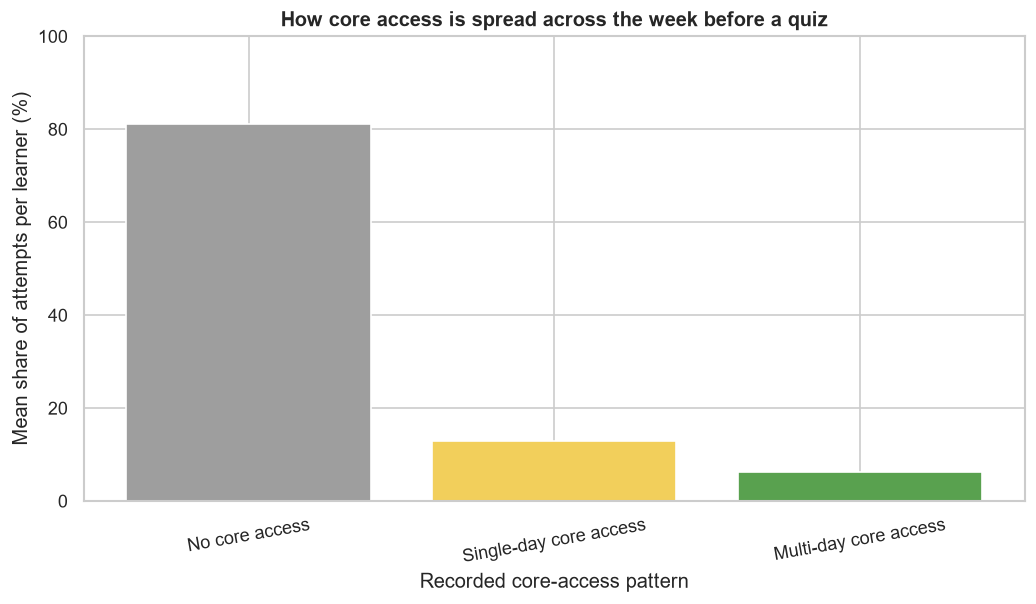

In [623]:
# Test the three RQ2 hypotheses with one learner-level comparison per test.
def r0_sign_test(differences, alternative="greater"):
    differences = pd.Series(differences).dropna()
    nonzero = differences.ne(0)
    n_tested = int(nonzero.sum())
    n_greater = int(differences.loc[nonzero].gt(0).sum())
    n_less = n_tested - n_greater
    p_value = (stats.binomtest(n_greater, n=n_tested, p=.5, alternative=alternative).pvalue
               if n_tested else np.nan)
    return n_tested, n_greater, n_less, float(p_value)

# H1: Is a typical learner's share of attempts without core access above 50%?
r0_user_no_core = r0_eligible14.assign(
    no_core=r0_eligible14.Core_week1_accesses.eq(0).astype(float)
).groupby("user_id").no_core.mean()
h1_tested, h1_greater, h1_less, h1_p = r0_sign_test(r0_user_no_core - .5, "greater")
h1_tied = int((r0_user_no_core - .5).eq(0).sum())
h1_n = len(r0_user_no_core)
h1_attempt_share = float(r0_eligible14.Core_week1_accesses.eq(0).mean())

# H2: Compare each learner's four-week attempt shares for interactive/media and core.
r0_material_shares = pd.DataFrame(index=r0_eligible28.user_id.unique())
for group_name in ["Core", "Extra-learning", "Interactive/media"]:
    cols = [f"{group_name}_week{week}_accesses" for week in range(1, 5)]
    active = r0_eligible28[cols].gt(0).any(axis=1).astype(float)
    r0_material_shares[group_name] = active.groupby(r0_eligible28.user_id).mean()
r0_material_shares = r0_material_shares.fillna(0)
h2_diff = r0_material_shares["Interactive/media"] - r0_material_shares["Core"]
h2_tested, h2_greater, h2_less, h2_p = r0_sign_test(h2_diff, "greater")
h2_tied = int(h2_diff.eq(0).sum())
h2_n = len(r0_material_shares)

# H3: Does either multi-day or single-day core access dominate within learners?
r0_core_attempts = r0_eligible14.loc[r0_eligible14.Core_week1_accesses.gt(0)].copy()
r0_core_attempts["multi_day"] = r0_core_attempts.Core_week1_active_days.ge(2).astype(float)
r0_core_attempts["single_day"] = r0_core_attempts.Core_week1_active_days.eq(1).astype(float)
r0_h3_users = r0_core_attempts.groupby("user_id")[["multi_day", "single_day"]].mean()
h3_diff = r0_h3_users.multi_day - r0_h3_users.single_day
h3_tested, h3_greater, h3_less, h3_p = r0_sign_test(h3_diff, "two-sided")
h3_tied = int(h3_diff.eq(0).sum())
h3_n = len(r0_h3_users)

# Adjust the three planned RQ2 p-values together using Holm's method.
def r0_holm_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    adjusted = np.full(values.shape, np.nan)
    valid = np.flatnonzero(np.isfinite(values))
    order = valid[np.argsort(values[valid])]
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(order) - rank) * values[idx])
        adjusted[idx] = min(1.0, running)
    return adjusted

holm_values = r0_holm_adjust([h1_p, h2_p, h3_p])
r0_hypothesis_results = pd.DataFrame([
    {"Hypothesis": "H1: More than half of attempts per learner have no core access in prior 7 days",
     "Learners": h1_n, "Learners in p-test": h1_tested,
     "Effect": f"No access in {h1_attempt_share:.1%} of attempts; learner tendency above/below/tied = {h1_greater}/{h1_less}/{h1_tied}",
     "p-value": h1_p, "Holm-adjusted p": holm_values[0]},
    {"Hypothesis": "H2: Interactive/media appears in more attempts than core across 28 days (exploratory)",
     "Learners": h2_n, "Learners in p-test": h2_tested,
     "Effect": f"Mean learner attempt shares: media = {r0_material_shares['Interactive/media'].mean():.1%}; core = {r0_material_shares['Core'].mean():.1%}; media/core/tied = {h2_greater}/{h2_less}/{h2_tied}",
     "p-value": h2_p, "Holm-adjusted p": holm_values[1]},
    {"Hypothesis": "H3: Learner preference differs between multi-day and single-day core access (two-sided; exploratory)",
     "Learners": h3_n, "Learners in p-test": h3_tested,
     "Effect": f"Learners favoring multi-day/single-day/tied = {h3_greater}/{h3_less}/{h3_tied}",
     "p-value": h3_p, "Holm-adjusted p": holm_values[2]},
])
r0_hypothesis_results["Decision"] = np.where(
    r0_hypothesis_results["Holm-adjusted p"].isna(), "Not testable",
    np.where(r0_hypothesis_results["Holm-adjusted p"].lt(.05), "Evidence for stated difference", "No clear evidence for stated difference"))
r0_display_results = r0_hypothesis_results.copy()
for col in ["p-value", "Holm-adjusted p"]:
    r0_display_results[col] = r0_display_results[col].map(
        lambda value: "Not testable" if pd.isna(value) else ("<0.001" if value < .001 else f"{value:.3f}"))
display(r0_display_results)

# Compare no, one-day, and multi-day core access in the prior week.
r0_attempt_patterns = r0_eligible14[["user_id", "Core_week1_accesses", "Core_week1_active_days"]].copy()
r0_attempt_patterns["pattern"] = np.select(
    [r0_attempt_patterns.Core_week1_accesses.eq(0), r0_attempt_patterns.Core_week1_active_days.eq(1),
     r0_attempt_patterns.Core_week1_active_days.ge(2)],
    ["No core access", "Single-day core access", "Multi-day core access"], default="Other")
r0_pattern_shares = r0_attempt_patterns.groupby("user_id").pattern.value_counts(
    normalize=True).unstack(fill_value=0).mean().reindex(
        ["No core access", "Single-day core access", "Multi-day core access"], fill_value=0)
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.bar(r0_pattern_shares.index, 100 * r0_pattern_shares.values,
       color=["#9E9E9E", "#F2CF5B", "#59A14F"])
ax.set(title="How core access is spread across the week before a quiz",
       xlabel="Recorded core-access pattern", ylabel="Mean share of attempts per learner (%)")
ax.tick_params(axis="x", rotation=10)
ax.set_ylim(0, 100)
save_pdf("rq2_03_single_vs_multiday.pdf")

r0_hypothesis_results.to_csv(OUTPUT_DIR / "rq2_hypothesis_tests.csv", index=False)
r0_prep.to_csv(OUTPUT_DIR / "rq2_attempt_preparation_features.csv", index=False)


## 7. RQ3: learner profiles and differential SPM

K-Means makes profiles from one row per learner using eight numeric activity counts: core-content accesses, active study days, distinct core resources, slide accesses, media accesses, self-learning resources, forum interactions, and non-practice quiz attempts. Counts are log-transformed and standardized on a separate clustering matrix; no category encoding is used. PCA shows the clustering input in two dimensions, so it may not display all profile separation.

SPM mines ordered actions within same-day chains, split when there is a gap over 30 minutes or a practice-quiz block. It reports the top ten patterns of length two or more by session support, plus differential patterns meeting the stated overall-support and learner-support-gap thresholds. This section is descriptive: profile patterns are not statistical proof of stable learner types.


K-Means numeric activity features: core_access_count, material_active_days, distinct_core_resources, slide_access, media_access, selflearning_access, forum_interactions, quiz_attempts
Missing values in K-Means input: 0


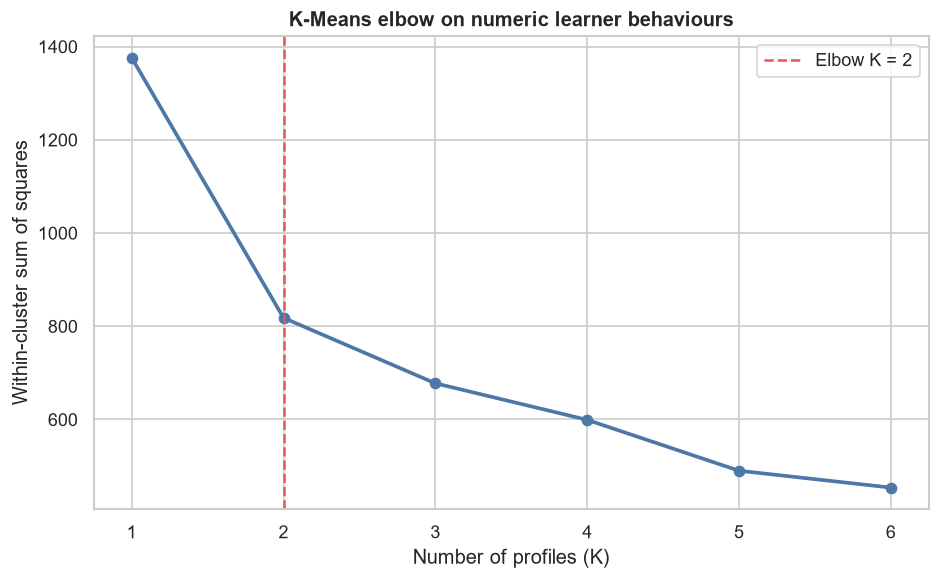

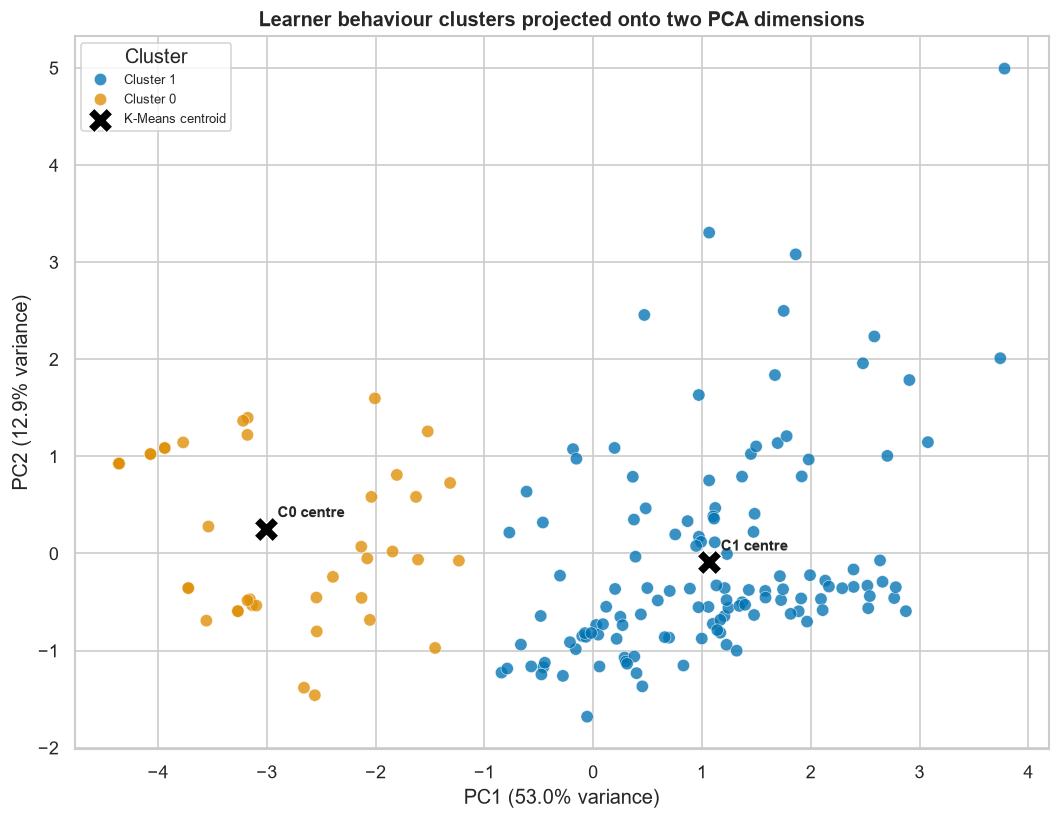

Elbow-selected K=2; learner counts by profile:


,profile,Learners,Learner share (0-1)
0,Cluster 0,45,0.262
1,Cluster 1,127,0.738


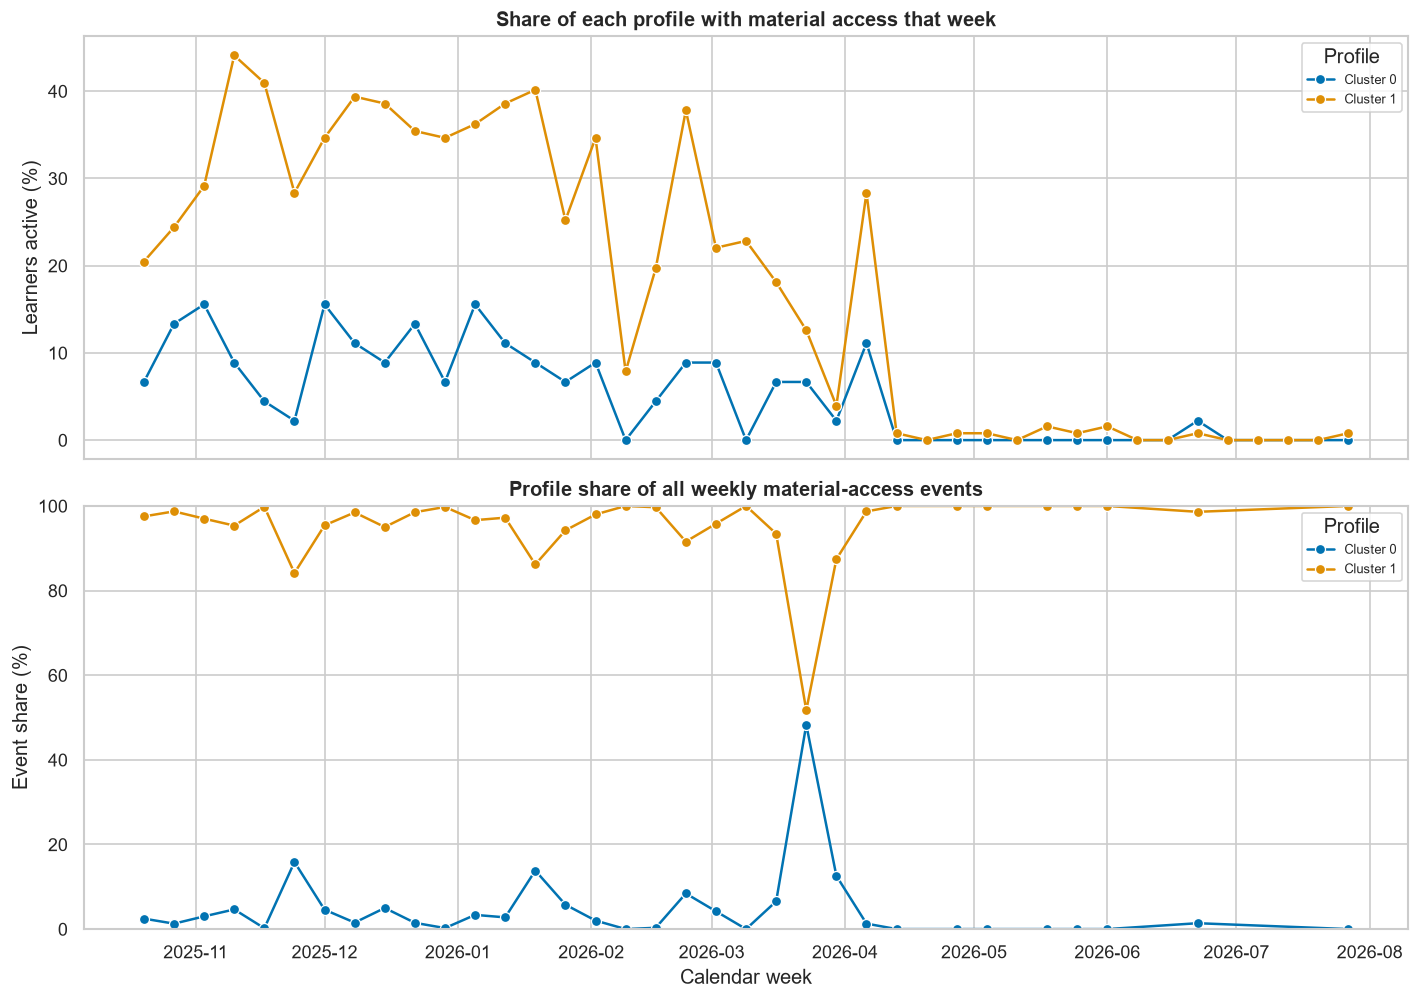

In [625]:
users = pd.Index(events.user_id.unique(), name="user_id")
all_users = users
profile = pd.DataFrame(index=users)
profile["material_event_count"] = resource_events.groupby("user_id").size().reindex(users, fill_value=0)
profile["core_access_count"] = core_events.groupby("user_id").size().reindex(users, fill_value=0)
profile["material_active_days"] = study_events.groupby("user_id").time.apply(lambda s: s.dt.normalize().nunique()).reindex(users, fill_value=0)
profile["distinct_materials"] = resource_events.groupby("user_id")["Event context"].nunique().reindex(users, fill_value=0)
profile["distinct_core_resources"] = core_events.groupby("user_id").resource_key.nunique().reindex(users, fill_value=0)
for kind, col in [
    ("Book chapters", "book_access"), ("Lecture slides", "slide_access"),
    ("Reference files", "reference_access"), ("Self-learning files", "selflearning_access"),
    ("Video/audio pages", "media_access"), ("Interactive SCORM", "scorm_access"),
]:
    profile[col] = resource_events.loc[resource_events.material_kind.eq(kind)].groupby("user_id").size().reindex(users, fill_value=0)
profile["course_home_views"] = events.loc[events.is_course_home].groupby("user_id").size().reindex(users, fill_value=0)
profile["forum_interactions"] = events.loc[events.is_forum_interaction].groupby("user_id").size().reindex(users, fill_value=0)
profile["quiz_attempts"] = cases.groupby("user_id").size().reindex(users, fill_value=0)
profile["quiz_submission_rate"] = cases.groupby("user_id").submitted.mean().reindex(users)
profile["mean_quiz_response_coverage"] = cases.groupby("user_id").quiz_response_coverage.mean().reindex(users)
profile["mean_quiz_answer_change_rate"] = cases.groupby("user_id").quiz_answer_change_rate.mean().reindex(users)
profile["mean_quiz_active_work_minutes"] = cases.groupby("user_id").quiz_active_work_minutes.mean().reindex(users)

# K-Means profiles use access/activity features only. Quiz submission and response outcomes
# stay out of the clustering so later quiz-pattern comparisons are not built into the labels.
count_cols = ["core_access_count", "material_active_days", "distinct_core_resources",
              "slide_access", "media_access", "selflearning_access", "forum_interactions", "quiz_attempts"]
cluster_cols = count_cols.copy()
cluster_matrix = profile[cluster_cols].astype(float).copy()
for col in count_cols:
    cluster_matrix[col] = np.log1p(cluster_matrix[col].clip(lower=0))
if cluster_matrix.isna().any().any():
    raise ValueError("K-Means activity features unexpectedly contain missing values.")
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(cluster_matrix)
print("K-Means numeric activity features:", ", ".join(cluster_cols))
print("Missing values in K-Means input:", int(cluster_matrix.isna().sum().sum()))
ks = np.arange(1, min(6, len(users) - 1) + 1)
inertia = [KMeans(n_clusters=int(k), n_init=10, random_state=42).fit(X_cluster).inertia_ for k in ks]
x_norm = (ks - ks.min()) / max(1, ks.max() - ks.min())
spread = inertia[0] - inertia[-1]
y_norm = (np.asarray(inertia) - inertia[-1]) / spread if spread > 0 else np.zeros(len(inertia))
bend = (1 - x_norm) - y_norm
chosen_k = int(ks[1 + np.argmax(bend[1:])])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, inertia, marker="o", linewidth=2.2, color="#4C78A8")
ax.axvline(chosen_k, color="#E45756", linestyle="--", label=f"Elbow K = {chosen_k}")
ax.set(title="K-Means elbow on numeric learner behaviours", xlabel="Number of profiles (K)", ylabel="Within-cluster sum of squares")
ax.set_xticks(ks)
ax.legend()
save_pdf("06_kmeans_elbow.pdf")

cluster_model = KMeans(n_clusters=chosen_k, n_init=20, random_state=42)
profile["cluster"] = cluster_model.fit_predict(X_cluster)
profile["profile"] = profile.cluster.map(lambda value: f"Cluster {int(value)}")

pca = PCA(n_components=2, random_state=42)
cluster_coordinates = pca.fit_transform(X_cluster)
centroid_coordinates = pca.transform(cluster_model.cluster_centers_)
cluster_plot = pd.DataFrame({"PC1": cluster_coordinates[:, 0], "PC2": cluster_coordinates[:, 1],
                             "Profile": profile["profile"].to_numpy()})
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=cluster_plot, x="PC1", y="PC2", hue="Profile", s=55, alpha=.78,
                edgecolor="white", linewidth=.35, palette="colorblind", ax=ax)
ax.scatter(centroid_coordinates[:, 0], centroid_coordinates[:, 1], marker="X", s=220,
           color="black", edgecolor="white", linewidth=.8, label="K-Means centroid", zorder=5)
for cluster_id, (cx, cy) in enumerate(centroid_coordinates):
    ax.annotate(f"C{cluster_id} centre", (cx, cy), xytext=(7, 7), textcoords="offset points",
                fontsize=9, weight="bold")
variance = pca.explained_variance_ratio_ * 100
ax.set(title="Learner behaviour clusters projected onto two PCA dimensions",
       xlabel=f"PC1 ({variance[0]:.1f}% variance)", ylabel=f"PC2 ({variance[1]:.1f}% variance)")
ax.legend(title="Cluster", frameon=True, fontsize=8)
save_pdf("07_kmeans_cluster_scatter.pdf")

profile_sizes = profile.groupby("profile").size().rename("Learners").reset_index()
profile_sizes["Learner share (0-1)"] = profile_sizes["Learners"] / max(1, len(profile))
print(f"Elbow-selected K={chosen_k}; learner counts by profile:")
display(profile_sizes.round(3))

learner_code = {uid: f"Learner {i:03d}" for i, uid in enumerate(sorted(users), start=1)}

# Profile-level weekly panel includes zero material-access weeks.
resource_week = resource_events.assign(week=resource_events.time.dt.to_period("W").dt.start_time)
user_week = resource_week.groupby(["user_id", "week"]).size().rename("accesses").reset_index()
weeks = pd.date_range(user_week.week.min(), user_week.week.max(), freq="W-MON")
panel = pd.MultiIndex.from_product([profile.index, weeks], names=["user_id", "week"]).to_frame(index=False)
panel = panel.merge(user_week, on=["user_id", "week"], how="left").fillna({"accesses": 0})
panel["profile"] = panel.user_id.map(profile.profile)
weekly_profile = panel.groupby(["week", "profile"], as_index=False).agg(
    active_share_pct=("accesses", lambda x: 100 * (x > 0).mean()), event_count=("accesses", "sum"))
weekly_profile["event_share_pct"] = 100 * weekly_profile.event_count / weekly_profile.groupby("week").event_count.transform("sum").replace(0, np.nan)
fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True)
sns.lineplot(data=weekly_profile, x="week", y="active_share_pct", hue="profile", marker="o", ax=axes[0])
axes[0].set(title="Share of each profile with material access that week", ylabel="Learners active (%)", xlabel="")
sns.lineplot(data=weekly_profile, x="week", y="event_share_pct", hue="profile", marker="o", ax=axes[1])
axes[1].set(title="Profile share of all weekly material-access events", ylabel="Event share (%)", xlabel="Calendar week", ylim=(0, 100))
axes[0].legend(title="Profile", fontsize=8)
axes[1].legend(title="Profile", fontsize=8)
save_pdf("05_weekly_material_activity_by_profile.pdf")


Example learner chains (each entry is one same-day, short-gap chain):


,Learner,Profile,Number of chains,Chains
0,Learner 001,Cluster 1,16,"[course_home → learning_page, course_home → le..."
1,Learner 002,Cluster 0,1,[course_home]
2,Learner 003,Cluster 0,15,"[course_home → learning_page, course_home → le..."
3,Learner 004,Cluster 0,12,"[course_home, course_home → learning_page, cou..."
4,Learner 005,Cluster 1,32,"[course_home, course_home, course_home → assig..."
5,Learner 006,Cluster 0,2,"[course_home, quiz_module → quiz_start → quiz_..."
6,Learner 007,Cluster 1,66,"[course_home, course_home, course_home, course..."
7,Learner 008,Cluster 1,9,"[course_home → learning_page → course_home, co..."


6,748 within-day sessions from 172 learners, spanning 238 dates.
Each pattern is counted once per session, even if it repeats within that session.
Top 10 multi-event patterns by session support (length >= 2):


,Pattern,Length,s-frequency (sessions),s-support (0-1),i-frequency (learners),i-support (0-1)
0,course_home → course_home,2,2055,0.305,163,0.948
1,course_home → course_home → course_home,3,1169,0.173,157,0.913
2,assignment_module → assignment_submission,2,1013,0.150,99,0.576
3,course_home → learning_page,2,922,0.137,142,0.826
4,course_home → file_open,2,747,0.111,145,0.843
5,course_home → scorm_module,2,737,0.109,135,0.785
6,course_home → assignment_module → assignment_s...,3,712,0.106,96,0.558
7,course_home → assignment_module,2,712,0.106,96,0.558
8,course_home → assignment_submission,2,712,0.106,96,0.558
9,scorm_module → scorm_launch,2,640,0.095,124,0.721


Differential patterns: overall s-support >= 0.01 and profile i-support gap >= 0.20.
Profile i-frequency is the number of learners in that profile with the pattern; i-support is the share of that profile.


,Pattern,s-frequency (sessions),s-support (0-1),i-frequency (learners),i-support (0-1),Profile i-support gap (0-1),Cluster 0 i-frequency (learners),Cluster 0 i-support (0-1),Cluster 1 i-frequency (learners),Cluster 1 i-support (0-1)
102,file_open → file_open → file_open,303,0.045,116,0.674,0.763,5,0.111,111,0.874
79,chapter_view → course_home,347,0.051,106,0.616,0.744,3,0.067,103,0.811
86,book_module → course_home,331,0.049,105,0.610,0.736,3,0.067,102,0.803
93,course_home → chapter_view → course_home,323,0.048,105,0.610,0.736,3,0.067,102,0.803
95,course_home → book_module → course_home,322,0.048,105,0.610,0.736,3,0.067,102,0.803
54,file_open → file_open → course_home,392,0.058,125,0.727,0.713,9,0.200,116,0.913
98,chapter_view → book_module → course_home,312,0.046,102,0.593,0.713,3,0.067,99,0.780
35,file_open → file_open,440,0.065,128,0.744,0.707,10,0.222,118,0.929
36,course_home → file_open → file_open,432,0.064,128,0.744,0.707,10,0.222,118,0.929
45,file_open → course_home → file_open,426,0.063,128,0.744,0.707,10,0.222,118,0.929


Top repeated patterns per pseudonymous learner:


,Learner,Profile,Pattern,s-frequency (sessions),Learner s-support (0-1),Learner sessions,Days represented
0,Learner 001,Cluster 1,course_home → file_open,9,0.562,16,8
1,Learner 003,Cluster 0,course_home → learning_page,10,0.667,15,8
2,Learner 004,Cluster 0,course_home → learning_page,11,0.917,12,4
3,Learner 004,Cluster 0,course_home → course_home,6,0.500,12,3
4,Learner 005,Cluster 1,course_home → course_home,18,0.562,32,13
5,Learner 005,Cluster 1,assignment_module → assignment_submission,16,0.500,32,14
6,Learner 007,Cluster 1,course_home → scorm_module,20,0.303,66,16
7,Learner 007,Cluster 1,scorm_module → scorm_launch,15,0.227,66,13
8,Learner 008,Cluster 1,course_home → course_home,3,0.333,9,3
9,Learner 008,Cluster 1,course_home → learning_page,3,0.333,9,3


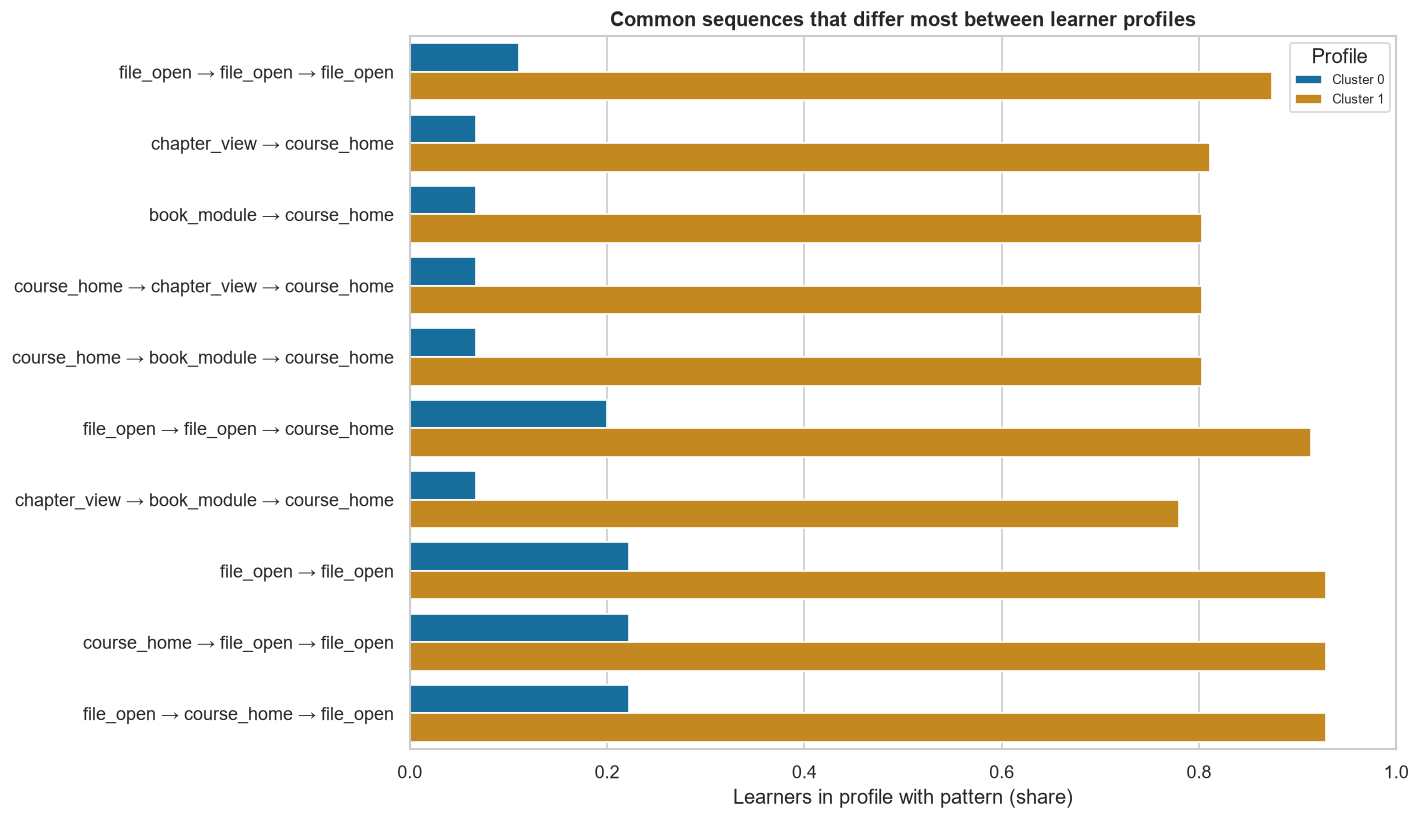

In [626]:
# Compact event tokens make sequence patterns readable.
def action_item(row):
    name, comp = str(row.event_name), str(row.component)
    fixed = {
        "Course viewed": "course_home",
        "Chapter viewed": "chapter_view",
        "Sco launched": "scorm_launch",
        "Quiz attempt started": "quiz_start",
        "Quiz attempt viewed": "quiz_page",
        "Quiz attempt updated": "answer_update",
        "Quiz attempt auto-saved": "autosave",
        "Quiz attempt submitted": "quiz_submit",
        "Quiz attempt summary viewed": "quiz_summary",
        "Quiz attempt reviewed": "quiz_review",
        "Discussion viewed": "discussion_view",
        "Discussion created": "forum_post",
        "Some content has been posted.": "forum_post",
    }
    if name in fixed:
        return fixed[name]
    if name == "Course module viewed":
        if comp == "Book": return "book_module"
        if comp == "SCORM package": return "scorm_module"
        if comp == "File":
            if row.material_kind == "Lecture slides": return "slides_open"
            if row.material_kind == "Reference files": return "reference_open"
            return "file_open"
        if comp == "Page": return "learning_page"
        return {"Quiz": "quiz_module", "Assignment": "assignment_module",
                "Forum": "forum_module", "Glossary": "glossary_module"}.get(comp, "module_view")
    if comp in ["File submissions", "Online text submissions"] or "submission" in name.lower():
        return "assignment_submission"
    if comp == "Assignment": return "assignment_action"
    if comp == "Forum": return "forum_action"
    if comp == "Glossary": return "glossary_action"
    return "other_action"

sequence_events = events.sort_values(["user_id", "time"]).copy()
sequence_events["item"] = sequence_events.apply(action_item, axis=1)
prev_user, prev_time = sequence_events.user_id.shift(), sequence_events.time.shift()
prev_date = sequence_events.time.dt.date.shift()
prev_practice = sequence_events.is_practice_quiz.shift().fillna(False)
new_session = (sequence_events.user_id.ne(prev_user)
               | sequence_events.time.dt.date.ne(prev_date)
               | sequence_events.time.sub(prev_time).gt(pd.Timedelta(minutes=30))
               | sequence_events.is_practice_quiz.ne(prev_practice))
sequence_events["session_number"] = new_session.groupby(sequence_events.user_id).cumsum().astype(int)
sequence_events["session_id"] = sequence_events.user_id.astype(str) + "_" + sequence_events.session_number.astype(str)
# Exclude practice-quiz actions after assigning IDs so they split, rather than bridge, nearby SPM sequences.
sequence_events = sequence_events.loc[~sequence_events.is_practice_quiz].copy()

def collapse(items):
    return tuple(item for i, item in enumerate(items) if i == 0 or item != items[i - 1])

sessions = sequence_events.groupby(["user_id", "session_id"], sort=False).agg(
    session_date=("time", lambda x: x.iloc[0].date()),
    start=("time", "min"), end=("time", "max"),
    event_rows=("time", "size"), items=("item", list),
).reset_index()
sessions["sequence"] = sessions["items"].map(collapse)
sessions["duration_min"] = (sessions.end - sessions.start).dt.total_seconds() / 60
sessions["learner_code"] = sessions.user_id.map(learner_code)
sessions["profile"] = sessions.user_id.map(profile.profile)

def mine_patterns(sequences, minimum, max_length=3):
    found = {}
    def grow(prefix, projected):
        extensions = {}
        for seq in projected:
            seen = set()
            for pos, item in enumerate(seq):
                if item not in seen:
                    extensions.setdefault(item, []).append(seq[pos + 1:])
                    seen.add(item)
        for item, suffixes in extensions.items():
            if len(suffixes) >= minimum:
                pattern = prefix + (item,)
                found[pattern] = len(suffixes)
                if len(pattern) < max_length:
                    grow(pattern, suffixes)
    grow(tuple(), list(sequences))
    return found

def contains(seq, pattern):
    pos = 0
    for item in seq:
        if pos < len(pattern) and item == pattern[pos]:
            pos += 1
    return pos == len(pattern)

# Keep every within-day chain visible, grouped under its learner.
learner_chain_rows = []
for uid, group in sessions.groupby("user_id", sort=False):
    learner_chain_rows.append({
        "Learner": learner_code[uid],
        "Profile": group.profile.iloc[0],
        "Number of chains": len(group),
        "Chains": [" → ".join(chain) for chain in group.sequence],
    })
learner_chains = pd.DataFrame(learner_chain_rows)
print("Example learner chains (each entry is one same-day, short-gap chain):")
display(learner_chains.head(8))

# Mine patterns of length 2+ overall and within each profile. Overall mining uses
# a 1% session-support floor so the top-frequency table is not limited to patterns
# that happen to pass the stricter per-profile candidate threshold.
all_sessions = len(sessions)
all_session_users = sessions.user_id.nunique()
min_overall_sessions = max(5, math.ceil(.01 * all_sessions))
found_overall = mine_patterns(sessions.sequence.tolist(), min_overall_sessions, max_length=3)
candidates = {pattern for pattern in found_overall if len(pattern) >= 2}
group_sessions, thresholds = {}, {}
for name, group in sessions.groupby("profile", sort=True):
    group_sessions[name] = group
    thresholds[name] = max(5, math.ceil(.02 * len(group)))
    found_profile = mine_patterns(group.sequence.tolist(), thresholds[name], max_length=3)
    candidates.update(pattern for pattern in found_profile if len(pattern) >= 2)

min_spm_support = .01
min_profile_gap = .20
pattern_rows = []
for pattern in candidates:
    matched = sessions.sequence.map(lambda seq: contains(seq, pattern))
    matched_sessions = sessions.loc[matched]
    session_frequency = int(matched.sum())
    learner_frequency = int(matched_sessions.user_id.nunique())
    row = {
        "Pattern": " → ".join(pattern),
        "Length": len(pattern),
        "s-frequency (sessions)": session_frequency,
        "s-support (0-1)": session_frequency / max(1, all_sessions),
        "i-frequency (learners)": learner_frequency,
        "i-support (0-1)": learner_frequency / max(1, all_session_users),
    }
    profile_i_supports = []
    for name, group in group_sessions.items():
        group_match = group.sequence.map(lambda seq: contains(seq, pattern))
        group_matched = group.loc[group_match]
        session_count = int(group_match.sum())
        learner_count = int(group_matched.user_id.nunique())
        row[f"{name} s-frequency (sessions)"] = session_count
        row[f"{name} s-support (0-1)"] = session_count / max(1, len(group))
        row[f"{name} i-frequency (learners)"] = learner_count
        learner_support = learner_count / max(1, group.user_id.nunique())
        row[f"{name} i-support (0-1)"] = learner_support
        profile_i_supports.append(learner_support)
    row["Profile i-support gap (0-1)"] = max(profile_i_supports) - min(profile_i_supports)
    pattern_rows.append(row)

spm = pd.DataFrame(pattern_rows)
if not spm.empty:
    spm = spm.sort_values(["s-support (0-1)", "i-frequency (learners)"], ascending=[False, False]).reset_index(drop=True)
    top10_spm = spm.loc[spm["Length"].ge(2)].head(10).copy()
    differential_spm = spm.loc[
        spm["Length"].ge(2)
        & spm["s-support (0-1)"].ge(min_spm_support)
        & spm["Profile i-support gap (0-1)"].ge(min_profile_gap)
    ].sort_values(["Profile i-support gap (0-1)", "s-support (0-1)"], ascending=[False, False]).head(10).copy()
else:
    top10_spm = pd.DataFrame()
    differential_spm = pd.DataFrame()

# Per-learner support is the fraction of that learner's own sessions containing a pattern.
personal_rows = []
for uid, group in sessions.groupby("user_id", sort=False):
    seqs = group.sequence.tolist()
    if len(seqs) < 2:
        continue
    found = mine_patterns(seqs, max(2, math.ceil(.2 * len(seqs))), max_length=3)
    repeated = [(pattern, count) for pattern, count in found.items() if len(pattern) >= 2]
    for pattern, count in sorted(repeated, key=lambda item: (-item[1], len(item[0]), item[0]))[:2]:
        matched = group.loc[group.sequence.map(lambda seq: contains(seq, pattern))]
        personal_rows.append({
            "Learner": learner_code[uid], "Profile": group.profile.iloc[0],
            "Pattern": " → ".join(pattern), "s-frequency (sessions)": int(count),
            "Learner s-support (0-1)": count / len(seqs),
            "Learner sessions": len(seqs), "Days represented": matched.session_date.nunique(),
        })
personal_patterns = pd.DataFrame(personal_rows)

print(f"{len(sessions):,} within-day sessions from {sessions.user_id.nunique():,} learners, spanning {sessions.session_date.nunique():,} dates.")
print("Each pattern is counted once per session, even if it repeats within that session.")
print("Top 10 multi-event patterns by session support (length >= 2):")
spm_display_cols = ["Pattern", "Length", "s-frequency (sessions)", "s-support (0-1)",
                    "i-frequency (learners)", "i-support (0-1)"]
if not top10_spm.empty:
    display(top10_spm[spm_display_cols].round(3))
else:
    print("No multi-event patterns met the SPM mining thresholds.")
print(f"Differential patterns: overall s-support >= {min_spm_support:.2f} and profile i-support gap >= {min_profile_gap:.2f}.")
print("Profile i-frequency is the number of learners in that profile with the pattern; i-support is the share of that profile.")
diff_cols = ["Pattern", "s-frequency (sessions)", "s-support (0-1)",
             "i-frequency (learners)", "i-support (0-1)", "Profile i-support gap (0-1)"]
for name in group_sessions:
    diff_cols.extend([f"{name} i-frequency (learners)", f"{name} i-support (0-1)"])
if not differential_spm.empty:
    display(differential_spm[diff_cols].round(3))
else:
    print("No patterns met both differential cutoffs.")
print("Top repeated patterns per pseudonymous learner:")
display(personal_patterns.head(20).round(3))

if not differential_spm.empty:
    plot_data = differential_spm.head(10).melt(
        id_vars="Pattern",
        value_vars=[f"{name} i-support (0-1)" for name in group_sessions],
        var_name="Profile", value_name="learner_support")
    plot_data["Profile"] = plot_data["Profile"].str.replace(" i-support (0-1)", "", regex=False)
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_data, x="learner_support", y="Pattern", hue="Profile", ax=ax)
    ax.set(title="Common sequences that differ most between learner profiles",
           xlabel="Learners in profile with pattern (share)", ylabel="", xlim=(0, 1))
    ax.legend(title="Profile", fontsize=8)
    save_pdf("09_differential_spm_support.pdf")
else:
    print("No multi-event patterns met both differential filters; review the top-10 SPM table without treating rare patterns as group evidence.")


## 8. Conclusions and limitations

### RQ1 — Preparation and quiz work

No preparation–quiz pair remains significant after FDR correction. The Ridge model also does not beat a mean-only response-coverage baseline. A few Spearman correlations are worth describing as weak-to-modest exploratory patterns, but their adjusted q-values exceed .05. We cannot identify a reliable preparation feature for quiz workflow from this log, and we cannot make claims about marks or correctness.

### RQ2 — Preparation before quizzes

H1 is supported: core-material access was absent from 81% of eligible prior-week attempts, and 123 of 151 learners had no-access on more than half of their attempts. H2 is supported as an exploratory result: interactive/media appeared in more four-week attempt histories than core material (learner mean 67.1% vs 53.6%; Holm-adjusted p about .001 with the three-test family). H3's two-sided test finds a difference in learner patterns (10 favor multi-day, 23 favor single-day, one tie; Holm-adjusted p about .035), with the observed direction favoring single-day access. Thus the data do not support a claim that multi-day preparation is more common. H3 was broadened after seeing the earlier directional result, so treat it as exploratory rather than confirmatory.

These are Moodle access records, not proof of reading, understanding, preparation quality, or quiz performance. Some learners may study offline or use resources not captured by these event categories. A quiz submission indicates recorded completion, not correctness.

### RQ3 — Learner profiles and sequences

K-Means uses recorded numeric activity only. PCA is a two-dimensional view and may not show all separation. The SPM table reports frequent ordered patterns of length two or more, their session frequency/support and learner frequency/support, plus patterns that differ across profiles. These profile differences are descriptive and are not statistical tests of stable learner types.


In [628]:
print("RQ1 prep × quiz correlation pairs with FDR q < .05:", int(significant_pairs.shape[0]))
display(association_summary.round(3))
display(regression_table)
display(pd.DataFrame([
    ["Learners profiled", len(profile)],
    ["Elbow-selected K", chosen_k],
    ["Sessions mined", len(sessions)],
    ["Candidate frequent sequences", len(candidates)],
    ["Learners with repeated personal patterns", personal_patterns.Learner.nunique() if not personal_patterns.empty else 0],
], columns=["RQ3 summary", "Value"]))

cross.to_csv(OUTPUT_DIR / "rq1_prep_quiz_correlations.csv", index=False)
association_summary.to_csv(OUTPUT_DIR / "rq1_quiz_feature_association_summary.csv", index=False)
regression_table.to_csv(OUTPUT_DIR / "rq1_response_coverage_regression.csv", index=False)
coefficients.to_csv(OUTPUT_DIR / "rq1_response_coverage_coefficients.csv", index=False)
cases[READ_FEATURES + QUIZ_FEATURES + ["quiz_name", "user_id", "case_id"]].to_csv(OUTPUT_DIR / "rq1_attempt_features.csv", index=False)
prep_window_summary.to_csv(OUTPUT_DIR / "rq1_preparation_window_summary.csv", index=False)
profile_sizes.to_csv(OUTPUT_DIR / "rq3_cluster_sizes.csv", index=False)
learner_chains_export = learner_chains.copy()
learner_chains_export["Chains"] = learner_chains_export["Chains"].map(lambda chains: json.dumps(chains, ensure_ascii=False))
learner_chains_export.to_csv(OUTPUT_DIR / "rq3_learner_session_chains.csv", index=False)
spm.to_csv(OUTPUT_DIR / "rq3_spm_all_patterns.csv", index=False)
top10_spm.to_csv(OUTPUT_DIR / "rq3_spm_top10_patterns.csv", index=False)
differential_spm.to_csv(OUTPUT_DIR / "rq3_spm_differential_patterns.csv", index=False)
personal_patterns.to_csv(OUTPUT_DIR / "rq3_learner_top_patterns.csv", index=False)
print(f"PDF figures and result tables saved in {OUTPUT_DIR}")
print("PDF figures:", ", ".join(sorted(p.name for p in OUTPUT_DIR.glob("*.pdf"))))


RQ1 prep × quiz correlation pairs with FDR q < .05: 0


,Quiz feature,Tested_prep_features,Significant_Pearson_features,Significant_Spearman_features,Strongest_abs_spearman
0,quiz_active_work_minutes,18,0,0,0.258
1,quiz_answer_change_rate,18,0,0,0.140
2,quiz_answered_pages,18,0,0,0.146
3,quiz_covered_pages,18,0,0,0.072
4,quiz_median_response_latency_min,18,0,0,0.266
5,quiz_pacing_iqr_min,18,0,0,0.181
6,quiz_page_revisit_share,18,0,0,0.166
7,quiz_pages_with_latency,18,0,0,0.084
8,quiz_prior_attempts_same_quiz,18,0,0,0.203
9,quiz_response_coverage,18,0,0,0.191


,Response-coverage regression,Result
0,Target,Updated pages / viewed pages (not quiz marks)
1,Train / held-out attempts,305 / 98
2,Learners held out,38
3,Preparation predictors,"prep_core_access_count_overall, prep_active_st..."
4,Ridge held-out R-squared,-0.018
5,Ridge held-out MAE,0.042
6,Mean-baseline held-out R-squared,-0.000
7,Mean-baseline held-out MAE,0.039


,RQ3 summary,Value
0,Learners profiled,172
1,Elbow-selected K,2
2,Sessions mined,6748
3,Candidate frequent sequences,1368
4,Learners with repeated personal patterns,153


PDF figures and result tables saved in C:\Users\mradu\Documents\Codex\2026-10-02\hi\outputs\moodle
PDF figures: 01_event_actions.pdf, 02_preparation_feature_correlation.pdf, 02_preparation_quiz_correlation.pdf, 02a_prep_quiz_pearson.pdf, 02b_prep_quiz_spearman.pdf, 03_weekly_event_families.pdf, 04_weekly_quiz_activity.pdf, 05_weekly_material_activity_by_profile.pdf, 06_kmeans_elbow.pdf, 07_kmeans_cluster_scatter.pdf, 07_kmeans_profile_comparison.pdf, 09_differential_spm_support.pdf, rq0_01_material_timing_before_quiz.pdf, rq0_02_core_weekly_trajectory.pdf, rq0_03_last_day_vs_baseline.pdf, rq0_03_single_vs_multiday.pdf, rq0_04_preparation_patterns.pdf, rq0_04_resource_breadth_by_days.pdf, rq0_05_last_day_vs_baseline.pdf, rq2_01_material_timing_before_quiz.pdf, rq2_02_core_weekly_trajectory.pdf, rq2_03_single_vs_multiday.pdf
